In [9]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ==========================================
# 1. DATASET DEFINITION
# ==========================================
class WriterDataset(Dataset):
    def __init__(self, dataframe, writer_id, img_dir='myDataset', transform=None):
        # Filter for the specific writer
        self.data = dataframe[dataframe['writer_id'] == writer_id].reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') # Convert to Grayscale
        if self.transform:
            image = self.transform(image)
        return image

# ==========================================
# 2. MODEL ARCHITECTURES
# ==========================================
'''class Generator(nn.Module):
    def __init__(self, latent_dim=100, channels_img=1, features_g=64):
        super(Generator, self).__init__()
        # Input: N x latent_dim x 1 x 1
        self.net = nn.Sequential(
            self._block(latent_dim, features_g * 16, 4, 1, 0),  # 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1), # 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1),  # 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1),  # 32x32
            nn.ConvTranspose2d(
                features_g * 2, channels_img, kernel_size=4, stride=2, padding=1
            ), # 64x64
            nn.Tanh(), # Output is in [-1, 1]
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)'''
class Generator(nn.Module):
    def __init__(self, latent_dim=100, channels_img=1, features_g=64):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Start with standard ConvTranspose for the very first 1x1 to 4x4 expansion
            nn.ConvTranspose2d(latent_dim, features_g * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(),
            
            # Use Upsample + Conv2d for the rest to avoid "dotted" checkerboard artifacts
            self._upsample_block(features_g * 16, features_g * 8), # 8x8
            self._upsample_block(features_g * 8, features_g * 4),  # 16x16
            self._upsample_block(features_g * 4, features_g * 2),  # 32x32
            
            # Final layer
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(features_g * 2, channels_img, kernel_size=3, stride=1, padding=1), # 64x64
            nn.Tanh(), 
        )

    def _upsample_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # Smoothly scales up 2x
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

def get_convnext_discriminator(device):
    """Loads and modifies a pre-trained ConvNeXt for 1-channel binary classification."""
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    # 1. Modify stem for 1-channel (grayscale) input
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(
        in_channels=1, 
        out_channels=original_stem.out_channels, 
        kernel_size=original_stem.kernel_size, 
        stride=original_stem.stride
    )
    
    # Optional: Freeze early layers to speed up training
    for param in disc.features[:-2].parameters():
        param.requires_grad = False
        
    # 2. Modify classifier for binary output (Real/Fake)
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    
    return disc.to(device)

# ==========================================
# 3. CROSS-EVALUATION FUNCTION
# ==========================================
def evaluate_other_writers(target_writer, saved_model_path, full_df, device, transform):
    """Uses a target writer's discriminator to score all other writers' data."""
    print(f"\n--- Cross-Evaluating Discriminator of Writer: {target_writer} ---")
    
    disc = get_convnext_discriminator(device)
    disc.load_state_dict(torch.load(saved_model_path, map_location=device))
    disc.eval()
    
    writers = full_df['writer_id'].unique()
    other_writers = [w for w in writers if w != target_writer]
    results = {}
    
    with torch.no_grad():
        for other_writer in other_writers:
            dataset = WriterDataset(full_df, writer_id=other_writer, transform=transform)
            loader = DataLoader(dataset, batch_size=64, shuffle=False)
            
            writer_scores = []
            for images in loader:
                images = images.to(device)
                scores = disc(images).view(-1).cpu().numpy()
                writer_scores.extend(scores)
                
            # Average probability that this data belongs to the target writer
            avg_score = sum(writer_scores) / len(writer_scores)
            results[other_writer] = avg_score
            print(f"Similarity score for {other_writer} against {target_writer}: {avg_score:.4f}")
            
    return results

# ==========================================
# 4. MAIN EXECUTION & TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    # Hyperparameters
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_EPOCHS = 50
    BATCH_SIZE = 32
    LATENT_DIM = 100
    LR = 0.0002
    SAVE_DIR = "saved_discriminators"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Load Data
    try:
        df1 = pd.read_csv('train.csv')
        df2 = pd.read_csv('additional_train.csv')
        full_df = pd.concat([df1, df2], ignore_index=True)
    except FileNotFoundError:
        print("Error: CSV files not found. Ensure they are in the same directory.")
        exit()

    # Get unique writers (excluding -1 if it represents unlabeled/test data)
    writers = [w for w in full_df['writer_id'].unique() if w != '-1' and w != 'nan']
    print(f"Total target writers for training: {len(writers)}")

    # Transforms (ConvNeXt can handle 64x64, though 128x128 might yield richer features)
    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    criterion = nn.BCELoss()

    # Main Loop: Train a GAN for each writer
    for writer in writers:
        if pd.isna(writer) or str(writer).lower() == 'nan':
            print(f"Skipping invalid writer ID: {writer}")
            continue
        print(f"\n{'='*40}")
        print(f"STARTING TRAINING FOR WRITER: {writer}")
        print(f"{'='*40}")
        
        dataset = WriterDataset(full_df, writer_id=writer,img_dir='myDataset', transform=transform)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        
        # Initialize fresh models for this writer
        gen = Generator(latent_dim=LATENT_DIM).to(DEVICE)
        disc = get_convnext_discriminator(DEVICE)
        
        opt_gen = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
        opt_disc = torch.optim.Adam(filter(lambda p: p.requires_grad, disc.parameters()), lr=0.00005, betas=(0.5, 0.999))
        
        for epoch in range(NUM_EPOCHS):
            for batch_idx, real in enumerate(loader):
                real = real.to(DEVICE)
                noise_to_add = torch.randn_like(real) * 0.05
                real_noisy = real
                batch_size = real.shape[0]
                
                # Create Labels
                real_labels = torch.full((batch_size, 1), 0.9).to(DEVICE)
                fake_labels = torch.full((batch_size, 1), 0.1).to(DEVICE)
                
                # ---------------------
                # Train Discriminator
                # ---------------------
                noise = torch.randn(batch_size, LATENT_DIM, 1, 1).to(DEVICE)
                fake = gen(noise)
                
                disc_real = disc(real).view(-1, 1)
                loss_disc_real = criterion(disc_real, real_labels)
                
                disc_fake = disc(fake.detach()).view(-1, 1)
                loss_disc_fake = criterion(disc_fake, fake_labels)
                
                loss_disc = (loss_disc_real + loss_disc_fake) / 2
                disc.zero_grad()
                loss_disc.backward()
                opt_disc.step()
                
                # ---------------------
                # Train Generator
                # ---------------------
                output = disc(fake).view(-1, 1)
                loss_gen = criterion(output, real_labels)
                
                gen.zero_grad()
                loss_gen.backward()
                opt_gen.step()

            # Save a visual sample and model weights every 5 epochs
            if (epoch + 1) % 5 == 0:
                with torch.no_grad():
                    test_noise = torch.randn(16, LATENT_DIM, 1, 1).to(DEVICE)
                    fake_samples = gen(test_noise).detach().cpu()
                    
                    # Save the image grid
                    img_path = os.path.join(SAVE_DIR, f"writer_{writer}_epoch_{epoch+1}.png")
                    vutils.save_image(fake_samples, img_path, normalize=True, nrow=4)
                        
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")
            
        # Save the fine-tuned ConvNeXt Discriminator for this specific writer
        save_path = os.path.join(SAVE_DIR, f"discriminator_{writer}.pth")
        torch.save(disc.state_dict(), save_path)   
        print(f"Saved completed discriminator to {save_path}")
        with torch.no_grad():
            # Create 16 random noise vectors
            test_noise = torch.randn(16, LATENT_DIM, 1, 1).to(DEVICE)
            # Generate images
            generated_images = gen(test_noise).detach().cpu()
            
            # Save a grid of the generated images
            img_save_path = os.path.join(SAVE_DIR, f"generated_samples_{writer}.png")
            # Normalize=True scales the [-1, 1] output back to [0, 1] for saving
            vutils.save_image(generated_images, img_save_path, normalize=True, nrow=4)
            print(f"Saved visual samples to {img_save_path}")
        

    # Example of Cross-Evaluation after all training is done
    # evaluate_other_writers('W27', os.path.join(SAVE_DIR, 'discriminator_W27.pth'), full_df, DEVICE, transform)

Total target writers for training: 45
Skipping invalid writer ID: nan

STARTING TRAINING FOR WRITER: W11


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np

class WriterDataset(Dataset):
    def __init__(self, dataframe, writer_id, img_dir='myDataset', transform=None):
        # Filter for the specific writer
        self.data = dataframe[dataframe['writer_id'] == writer_id].reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') # Convert to Grayscale
        if self.transform:
            image = self.transform(image)
        return image

def get_convnext_discriminator(device):
    """Loads and modifies a pre-trained ConvNeXt for 1-channel binary classification."""
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    # 1. Modify stem for 1-channel (grayscale) input
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(
        in_channels=1, 
        out_channels=original_stem.out_channels, 
        kernel_size=original_stem.kernel_size, 
        stride=original_stem.stride
    )
    
    # Optional: Freeze early layers to speed up training
    for param in disc.features[:-2].parameters():
        param.requires_grad = False
        
    # 2. Modify classifier for binary output (Real/Fake)
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    
    return disc.to(device)


if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "saved_discriminators"
    
    # 1. Load the Dataset
    print("Loading data...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    full_df = full_df.dropna(subset=['writer_id'])
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Filter valid writers
    writers = sorted([w for w in full_df['writer_id'].unique() if w != '-1' and w != 'nan'])
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    # Initialize an empty 45x45 matrix (DataFrame) to store the scores
    similarity_matrix = pd.DataFrame(index=writers, columns=writers)

    print(f"Starting Cross-Evaluation for {len(writers)} writers on {DEVICE}...")

    # 2. Outer Loop: The Evaluator (The trained Discriminator)
    for evaluator_writer in writers:
        model_path = os.path.join(SAVE_DIR, f"discriminator_{evaluator_writer}.pth")
        
        if not os.path.exists(model_path):
            print(f"Warning: Model for {evaluator_writer} not found. Skipping.")
            continue
            
        print(f"\n[{evaluator_writer}] Loading Discriminator...")
        disc = get_convnext_discriminator(DEVICE)
        disc.load_state_dict(torch.load(model_path, map_location=DEVICE))
        disc.eval() # Set to evaluation mode!
        
        # 3. Inner Loop: The Data (Testing all writers against this discriminator)
        with torch.no_grad():
            for target_writer in writers:
                dataset = WriterDataset(full_df, writer_id=target_writer, img_dir='myDataset', transform=transform)
                
                # Skip empty datasets
                if len(dataset) == 0:
                    continue
                    
                loader = DataLoader(dataset, batch_size=64, shuffle=False)
                
                all_scores = []
                for images in loader:
                    images = images.to(DEVICE)
                    # The discriminator outputs a value between 0 and 1
                    scores = disc(images).view(-1).cpu().numpy()
                    all_scores.extend(scores)
                
                # Calculate the average authenticity score
                avg_score = np.mean(all_scores)
                
                # Store it in the matrix: Row = Evaluator, Column = Target Data
                similarity_matrix.loc[evaluator_writer, target_writer] = avg_score
                
        print(f"Finished evaluating all data against {evaluator_writer}'s model.")

    # 4. Save the final results!
    matrix_save_path = "writer_similarity_matrix.csv"
    similarity_matrix.to_csv(matrix_save_path)
    print(f"\nSuccess! Full evaluation matrix saved to {matrix_save_path}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_similarity_heatmap(csv_path='writer_similarity_matrix.csv', save_path='heatmap_results.png'):
    print(f"Loading matrix from {csv_path}...")
    
    # 1. Load the CSV. We use index_col=0 because pandas saves the row names in the first column
    df = pd.read_csv(csv_path, index_col=0)
    
    # Ensure data is numeric (just in case)
    df = df.apply(pd.to_numeric)

    # 2. Set up the figure size
    # 18x15 inches provides plenty of room for 45 rows/columns
    plt.figure(figsize=(18, 15))
    sns.set_theme(style="white")

    print("Generating heatmap...")
    # 3. Create the Heatmap
    # cmap="YlGnBu" goes from light yellow (0.0/fake) to dark blue (1.0/real)
    # annot=False because 2,025 numbers would clutter the screen
    ax = sns.heatmap(df, 
                     annot=False,      
                     cmap="YlGnBu",    
                     vmin=0.0,         # Minimum score is 0
                     vmax=1.0,         # Maximum score is 1
                     square=True,      # Keep the grid cells perfectly square
                     linewidths=0.5,   # Add a tiny grid line between cells
                     cbar_kws={"shrink": 0.75, "label": "Similarity Score (0.0 = Fake, 1.0 = Real)"})

    # 4. Add Titles and Labels
    plt.title('GAN Cross-Evaluation: 45x45 Writer Similarity Matrix', fontsize=20, pad=20, fontweight='bold')
    plt.xlabel('Target Data (Writer Data Being Evaluated)', fontsize=14, labelpad=15)
    plt.ylabel('Evaluator Model (The Discriminator)', fontsize=14, labelpad=15)

    # 5. Format the tick marks (Writer IDs) so they don't overlap
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    # 6. Save the High-Resolution Image
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Success! Heatmap saved as '{save_path}'")
    
    # plt.show() # Uncomment this if you are running inside a Jupyter Notebook

if __name__ == "__main__":
    plot_similarity_heatmap()

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from tqdm import tqdm # Optional: for progress bars

# ==========================================
# 1. TEST DATASET CLASS
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir='', transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Build path and load image
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        
        if self.transform:
            image = self.transform(image)
            
        # Return both the image and its ID so we can map predictions later
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id

# ==========================================
# 2. MODEL DEFINITION
# ==========================================
def get_convnext_discriminator(device):
    # (PASTE YOUR EXACT DISCRIMINATOR FUNCTION HERE)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    return disc.to(device)

# ==========================================
# 3. MAIN INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "saved_discriminators"
    TEST_CSV = "myDataset/test.csv" # Change to "test (1).csv" if needed
    BASE_DIR = "myDataset"
    
    # 1. Load Test Data
    print("Loading test dataset...")
    test_df = pd.read_csv(TEST_CSV)
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    test_dataset = TestDataset(test_df, img_dir=BASE_DIR, transform=transform)
    # Batch size can be larger during inference since we don't store gradients
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    # 2. Identify all trained models
    # This automatically finds all saved .pth files and extracts the writer IDs
    model_files = [f for f in os.listdir(SAVE_DIR) if f.startswith("discriminator_") and f.endswith(".pth")]
    
    # Optional: If you trained '-1' but DON'T want to predict it, uncomment the line below:
    # model_files = [f for f in model_files if "-1" not in f]
    
    writers = [f.replace("discriminator_", "").replace(".pth", "") for f in model_files]
    print(f"Found {len(writers)} trained discriminator models.")

    # Dictionary to store the scores. Format: {image_id: {W11: 0.8, W35: 0.2, ...}}
    results_dict = {img_id: {} for img_id in test_df['image_id']}

    # 3. Evaluate Test Set against EVERY Discriminator
    for writer, model_file in zip(writers, model_files):
        print(f"Evaluating test set using {writer}'s model...")
        
        # Load Model
        model_path = os.path.join(SAVE_DIR, model_file)
        disc = get_convnext_discriminator(DEVICE)
        disc.load_state_dict(torch.load(model_path, map_location=DEVICE))
        disc.eval() # CRITICAL for inference!
        
        with torch.no_grad():
            for images, image_ids in test_loader:
                images = images.to(DEVICE)
                
                # Get authenticity scores for this batch
                scores = disc(images).view(-1).cpu().numpy()
                
                # Save scores to dictionary
                for img_id, score in zip(image_ids, scores):
                    results_dict[img_id][writer] = score

    # 4. Find the winning Writer ID for each image
    print("\nCalculating final predictions (Argmax)...")
    final_predictions = []

    CONFIDENCE_THRESHOLD= 0.50
    
    for img_id in test_df['image_id']:
        writer_scores = results_dict[img_id]
        
        # Find the writer_id with the MAXIMUM score
        #best_writer = max(writer_scores, key=writer_scores.get)
        
        #final_predictions.append({
            #'image_id': img_id,
            #'writer_id': best_writer
        #})
        # Find the maximum score and the writer who gave it
        best_writer = max(writer_scores, key=writer_scores.get)
        max_score = writer_scores[best_writer]
        
        # Threshold Check
        if max_score < CONFIDENCE_THRESHOLD:
            # None of the 45 models claimed this image with high confidence
            final_predictions.append({
                'image_id': img_id,
                'writer_id': '-1'
            })
        else:
            # We have a confident match!
            final_predictions.append({
                'image_id': img_id,
                'writer_id': best_writer
            })

    # 5. Format and Save to CSV
    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    '''print("\nSUCCESS! Submission file generated: submission_writer.csv")
    print(submission_df.head(10))

    # 4. Find the winning Writer ID for each image using Z-Scores
    print("\nApplying Z-Score Normalization to calibrate models...")
    
    # Convert results_dict to a Pandas DataFrame
    # Rows = image_ids, Columns = writer_ids
    scores_df = pd.DataFrame.from_dict(results_dict, orient='index')
    
    # Normalize each model (column) using Z-scores
    # This subtracts the model's average score and divides by its standard deviation
    z_scores_df = (scores_df - scores_df.mean()) / scores_df.std()
    
    final_predictions = []
    
    # --- THE Z-SCORE THRESHOLD ---
    # A Z-score of 1.5 means the model is 1.5 standard deviations more confident 
    # than its normal baseline. 
    # Try 1.5 or 2.0 here instead of standard probability decimals.
    Z_THRESHOLD = 1.5 
    
    for img_id in scores_df.index:
        # Get the Z-scores for this specific image across all 45 models
        image_z_scores = z_scores_df.loc[img_id]
        
        # Find the writer with the HIGHEST Z-score spike
        best_writer = image_z_scores.idxmax()
        max_z = image_z_scores.max()
        
        # Threshold Check
        if max_z < Z_THRESHOLD:
            # No model had a significant confidence spike
            final_predictions.append({
                'image_id': img_id,
                'writer_id': '-1'
            })
        else:
            final_predictions.append({
                'image_id': img_id,
                'writer_id': best_writer
            })
            
    # 5. Format and Save to CSV
    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! Calibrated submission file generated: submission_writer.csv")
    print(submission_df['writer_id'].value_counts().head(10)) # Print the top predicted writers to verify!'''

SystemError: <built-in function isinstance> returned a result with an exception set

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import seaborn as sns

# ==========================================
# PASTE YOUR CLASSES HERE:
# 1. WriterDataset class
# 2. get_convnext_discriminator() function
# ==========================================

if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "saved_discriminators"
    BASE_DIR = "myDataset"
    
    # 1. Load Data
    print("Loading data...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Extract ALL -1 images, and sample 500 of them to save time
    unknown_df = full_df[full_df['writer_id'] == '-1'].sample(n=500, random_state=42)
    
    # Extract known writers, and sample 500 of them
    known_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'] != 'nan')].sample(n=500, random_state=42)
    
    eval_df = pd.concat([unknown_df, known_df]).reset_index(drop=True)
    
    # True labels for the ROC curve: 0 for Unknown (-1), 1 for Known
    true_labels = (eval_df['writer_id'] != '-1').astype(int).values
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    dataset = WriterDataset(eval_df, writer_id=None, img_dir=BASE_DIR, transform=transform)
    # Override the init behavior since we want ALL images in eval_df, not filtered by writer_id
    dataset.data = eval_df 
    loader = DataLoader(dataset, batch_size=128, shuffle=False)

    # 2. Get the models
    model_files = [f for f in os.listdir(SAVE_DIR) if f.startswith("discriminator_") and f.endswith(".pth")]
    writers = [f.replace("discriminator_", "").replace(".pth", "") for f in model_files]
    
    # Initialize an array to hold the maximum score each image gets across ALL models
    max_scores = np.zeros(len(eval_df))

    # 3. Evaluate the images against all 45 models
    print("Evaluating sampled images against all models. This will take a moment...")
    for writer, model_file in zip(writers, model_files):
        model_path = os.path.join(SAVE_DIR, model_file)
        disc = get_convnext_discriminator(DEVICE)
        disc.load_state_dict(torch.load(model_path, map_location=DEVICE))
        disc.eval()
        
        all_scores_for_this_model = []
        with torch.no_grad():
            for images in loader:
                images = images.to(DEVICE)
                scores = disc(images).view(-1).cpu().numpy()
                all_scores_for_this_model.extend(scores)
                
        # Update max_scores: Keep the highest score seen so far for each image
        max_scores = np.maximum(max_scores, all_scores_for_this_model)

    # 4. Calculate the Optimal Threshold mathematically
    fpr, tpr, thresholds = roc_curve(true_labels, max_scores)
    # Youden's J statistic maximizes the difference between TPR and FPR
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"\n======================================")
    print(f"MATHEMATICALLY OPTIMAL THRESHOLD: {optimal_threshold:.4f}")
    print(f"======================================")

    # 5. Visualize the Distributions
    plt.figure(figsize=(10, 6))
    sns.histplot(max_scores[true_labels == 0], color='red', label='Unknown Writers (-1)', kde=True, stat="density", bins=30, alpha=0.5)
    sns.histplot(max_scores[true_labels == 1], color='blue', label='Known Writers', kde=True, stat="density", bins=30, alpha=0.5)
    
    plt.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Optimal Threshold ({optimal_threshold:.2f})')
    
    plt.title('Distribution of Max Confidence Scores: Known vs Unknown')
    plt.xlabel('Maximum Confidence Score (from any of the 45 models)')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.savefig('threshold_analysis.png')
    print("Saved distribution plot to 'threshold_analysis.png'.")

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ==========================================
# PASTE YOUR CLASSES HERE:
# 1. TestDataset class
# 2. get_convnext_discriminator() function
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir='', transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Build path and load image
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        
        if self.transform:
            image = self.transform(image)
            
        # Return both the image and its ID so we can map predictions later
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id

def get_convnext_discriminator(device):
    # (PASTE YOUR EXACT DISCRIMINATOR FUNCTION HERE)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    return disc.to(device)

if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "saved_discriminators"
    TEST_CSV = "myDataset/test.csv"
    BASE_DIR = "myDataset"
    
    print("Loading test dataset...")
    test_df = pd.read_csv(TEST_CSV)
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    test_dataset = TestDataset(test_df, img_dir=BASE_DIR, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    model_files = [f for f in os.listdir(SAVE_DIR) if f.startswith("discriminator_") and f.endswith(".pth")]
    writers = [f.replace("discriminator_", "").replace(".pth", "") for f in model_files]
    
    results_dict = {img_id: {} for img_id in test_df['image_id']}

    # Evaluate against all models
    for writer, model_file in zip(writers, model_files):
        print(f"Evaluating test set using {writer}'s model...")

        model_path = os.path.join(SAVE_DIR, model_file)
        disc = get_convnext_discriminator(DEVICE)
        disc.load_state_dict(torch.load(model_path, map_location=DEVICE))
        disc.eval() 
        
        with torch.no_grad():
            for images, image_ids in test_loader:
                images = images.to(DEVICE)
                scores = disc(images).view(-1).cpu().numpy()
                for img_id, score in zip(image_ids, scores):
                    results_dict[img_id][writer] = score

    # 4. Find the winning Writer ID using Baseline Subtraction
    print("\nApplying Baseline Subtraction to calibrate models...")
    
    # Convert results_dict to a Pandas DataFrame
    scores_df = pd.DataFrame.from_dict(results_dict, orient='index')
    
    # THE MAGIC FIX: Subtract each model's average score from its predictions
    # This completely neutralizes W14's dark horizontal band from the heatmap
    adjusted_scores_df = scores_df - scores_df.mean()
    
    final_predictions = []
    
    # --- THE SPIKE THRESHOLD ---
    # 0.20 means a model's confidence must spike at least 20% ABOVE its normal baseline
    # to claim an image. If no model spikes, it is an unknown writer (-1).
    SPIKE_THRESHOLD = 0.20 
    
    for img_id in scores_df.index:
        image_adjusted_scores = adjusted_scores_df.loc[img_id]
        
        # Find the writer with the biggest confidence spike
        best_writer = image_adjusted_scores.idxmax()
        max_spike = image_adjusted_scores.max()
        
        # Threshold Check
        if max_spike < SPIKE_THRESHOLD:
            final_predictions.append({
                'image_id': img_id,
                'writer_id': '-1'
            })
        else:
            final_predictions.append({
                'image_id': img_id,
                'writer_id': best_writer
            })
            
    # 5. Format and Save to CSV
    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! Baseline-subtracted file generated: submission_writer.csv")
    print(submission_df['writer_id'].value_counts().head(10))

Loading test dataset...
Evaluating test set using W39's model...
Evaluating test set using W27's model...
Evaluating test set using W04's model...
Evaluating test set using W30's model...
Evaluating test set using W24's model...
Evaluating test set using W45's model...
Evaluating test set using W13's model...
Evaluating test set using W38's model...
Evaluating test set using W41's model...
Evaluating test set using W11's model...
Evaluating test set using W08's model...
Evaluating test set using W46's model...
Evaluating test set using W50's model...
Evaluating test set using W19's model...
Evaluating test set using W36's model...
Evaluating test set using W49's model...
Evaluating test set using W42's model...
Evaluating test set using W23's model...
Evaluating test set using W03's model...
Evaluating test set using W17's model...
Evaluating test set using W48's model...
Evaluating test set using W43's model...
Evaluating test set using W40's model...
Evaluating test set using W25's m

In [10]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# PASTE YOUR CLASSES HERE:
# 1. WriterDataset / TestDataset classes
# 2. get_convnext_discriminator() function
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir='', transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Build path and load image
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        
        if self.transform:
            image = self.transform(image)
            
        # Return both the image and its ID so we can map predictions later
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id


def get_convnext_discriminator(device):
    # (PASTE YOUR EXACT DISCRIMINATOR FUNCTION HERE)
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    return disc.to(device)


if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "saved_discriminators"
    BASE_DIR = "myDataset"
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    # 1. IDENTIFY ALL MODELS
    model_files = [f for f in os.listdir(SAVE_DIR) if f.startswith("discriminator_") and f.endswith(".pth")]
    writers = [f.replace("discriminator_", "").replace(".pth", "") for f in model_files]
    
    print(f"Loading {len(writers)} models into memory...")
    models_dict = {}
    for writer, model_file in zip(writers, model_files):
        print(f"Evaluating test set using {writer}'s model...")
        model_path = os.path.join(SAVE_DIR, model_file)
        disc = get_convnext_discriminator(DEVICE)
        disc.load_state_dict(torch.load(model_path, map_location=DEVICE))
        disc.eval()
        models_dict[writer] = disc

    # ==========================================
    # PHASE 1: CREATE META-TRAINING DATA
    # ==========================================
    print("\n[PHASE 1] Extracting features for Meta-Classifier...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_train_df = pd.concat([df1, df2], ignore_index=True)
    full_train_df['writer_id'] = full_train_df['writer_id'].astype(str)
    
    # Sample data to train the Random Forest quickly (e.g., 1000 known, 1000 unknown)
    train_unknown = full_train_df[full_train_df['writer_id'] == '-1']
    train_known = full_train_df[(full_train_df['writer_id'] != '-1') & (full_train_df['writer_id'] != 'nan')]
    meta_train_df = pd.concat([train_unknown, train_known]).reset_index(drop=True)
    
    # We will use WriterDataset just to load the images easily
    meta_dataset = WriterDataset(meta_train_df, writer_id=None, img_dir=BASE_DIR, transform=transform)
    meta_dataset.data = meta_train_df # Override to use our combined subset
    meta_loader = DataLoader(meta_dataset, batch_size=128, shuffle=False)

    # Extract 45-dimensional features for the training set
    X_train = {writer: [] for writer in writers}
    Y_train = meta_train_df['writer_id'].values

    with torch.no_grad():
        for images in meta_loader:
            images = images.to(DEVICE)
            for writer, disc in models_dict.items():
                scores = disc(images).view(-1).cpu().numpy()
                X_train[writer].extend(scores)

    # Convert to standard scikit-learn X matrix (Rows = images, Columns = 45 models)
    X_train_matrix = pd.DataFrame(X_train).values

    # ==========================================
    # PHASE 2: TRAIN META-CLASSIFIER
    # ==========================================
    print("\n[PHASE 2] Training Random Forest Meta-Classifier...")
    # The Random Forest will figure out the optimal thresholds and handle "lazy" models like W14 automatically
    rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    rf.fit(X_train_matrix, Y_train)
    print("Meta-Classifier trained successfully!")

    # ==========================================
    # PHASE 3: INFERENCE ON TEST SET
    # ==========================================
    print("\n[PHASE 3] Evaluating Kaggle Test Set...")
    test_df = pd.read_csv("myDataset/test.csv")
    test_dataset = TestDataset(test_df, img_dir=BASE_DIR, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    X_test = {writer: [] for writer in writers}
    image_ids_list = []

    with torch.no_grad():
        for images, img_ids in test_loader:
            images = images.to(DEVICE)
            image_ids_list.extend(img_ids)
            for writer, disc in models_dict.items():
                scores = disc(images).view(-1).cpu().numpy()
                X_test[writer].extend(scores)

    X_test_matrix = pd.DataFrame(X_test).values

    # Predict using the trained Random Forest
    predictions = rf.predict(X_test_matrix)

    # Save Submission
    submission_df = pd.DataFrame({
        'image_id': image_ids_list,
        'writer_id': predictions
    })
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! Stacking submission generated: submission_writer.csv")
    print(submission_df['writer_id'].value_counts().head(10))

Loading 44 models into memory...
Evaluating test set using W39's model...
Evaluating test set using W27's model...
Evaluating test set using W04's model...
Evaluating test set using W30's model...
Evaluating test set using W24's model...
Evaluating test set using W45's model...
Evaluating test set using W13's model...
Evaluating test set using W38's model...
Evaluating test set using W41's model...
Evaluating test set using W11's model...
Evaluating test set using W08's model...
Evaluating test set using W46's model...
Evaluating test set using W50's model...
Evaluating test set using W19's model...
Evaluating test set using W36's model...
Evaluating test set using W49's model...
Evaluating test set using W42's model...
Evaluating test set using W23's model...
Evaluating test set using W03's model...
Evaluating test set using W17's model...
Evaluating test set using W48's model...
Evaluating test set using W43's model...
Evaluating test set using W40's model...
Evaluating test set usin

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split

# ==========================================
# 1. DATASET & MAPPING
# ==========================================
class UnifiedWriterDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
            
        label = self.data.loc[idx, 'encoded_label']
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 2. THE AC-GAN ARCHITECTURE
# ==========================================
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=45, embed_size=50, features_g=64):
        super().__init__()
        # Embedding layer for Writer IDs
        self.embed = nn.Embedding(num_classes, embed_size)
        
        # Generator upsampling blocks
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim + embed_size, features_g * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(),
            self._upsample_block(features_g * 16, features_g * 8), # 8x8
            self._upsample_block(features_g * 8, features_g * 4),  # 16x16
            self._upsample_block(features_g * 4, features_g * 2),  # 32x32
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(features_g * 2, 1, kernel_size=3, stride=1, padding=1), # 64x64
            nn.Tanh(), 
        )

    def _upsample_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, noise, labels):
        embedding = self.embed(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, embedding], dim=1) # Combine noise and writer condition
        return self.net(x)

def get_acgan_discriminator(device, num_classes=45):
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    # Modify stem for 1-channel grayscale
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Identity() # Remove default classifier
    
    # Custom Dual-Head 
    class DualOutputConvNeXt(nn.Module):
        def __init__(self, base_model, in_features, classes):
            super().__init__()
            self.features = base_model
            # Head 1: Real vs Fake (Authenticity)
            self.adv_head = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
            # Head 2: Which Writer? (Classification)
            self.class_head = nn.Linear(in_features, classes) 
            
        def forward(self, x):
            features = self.features(x)
            validity = self.adv_head(features)
            label_pred = self.class_head(features)
            return validity, label_pred

    return DualOutputConvNeXt(disc, num_ftrs, num_classes).to(device)


# ==========================================
# 3. TRAINING AND VALIDATION LOOP
# ==========================================
if __name__ == "__main__":
    # --- HYPERPARAMETERS ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 64
    LATENT_DIM = 100
    NUM_EPOCHS = 50
    LR_GEN = 0.0002
    LR_DISC = 0.0001
    BASE_DIR = "myDataset"
    
    print(f"Using device: {DEVICE}")

    # --- DATA PREP & SPLIT ---
    print("Loading and preparing data...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    
    # Exclude '-1' for training. The network must learn precise boundaries of the known 45.
    full_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'].notna())].copy()
    
    # Map Writer IDs to integers (0 to 44) for CrossEntropyLoss
    unique_writers = sorted(full_df['writer_id'].unique())
    NUM_CLASSES = len(unique_writers)
    writer_to_idx = {writer: idx for idx, writer in enumerate(unique_writers)}
    full_df['encoded_label'] = full_df['writer_id'].map(writer_to_idx)
    
    # Save the mapping so we can translate back during inference!
    pd.DataFrame(list(writer_to_idx.items()), columns=['writer_id', 'encoded_label']).to_csv('writer_mapping.csv', index=False)

    # 85% Train, 15% Validation split (stratified ensures equal writer distribution)
    train_df, val_df = train_test_split(full_df, test_size=0.15, stratify=full_df['encoded_label'], random_state=42)
    
    print(f"Train Set: {len(train_df)} images | Validation Set: {len(val_df)} images")

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        # Adding slight augmentation to prevent Discriminator overfitting
        transforms.RandomRotation(10), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    train_loader = DataLoader(UnifiedWriterDataset(train_df, BASE_DIR, transform), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(UnifiedWriterDataset(val_df, BASE_DIR, val_transform), batch_size=BATCH_SIZE, shuffle=False)

    # --- INIT MODELS ---
    gen = ConditionalGenerator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(DEVICE)
    disc = get_acgan_discriminator(DEVICE, num_classes=NUM_CLASSES)

    # --- LOSSES & OPTIMIZERS ---
    criterion_adv = nn.BCELoss()           # For Real/Fake
    criterion_cls = nn.CrossEntropyLoss()  # For Writer Classification
    
    opt_gen = optim.Adam(gen.parameters(), lr=LR_GEN, betas=(0.5, 0.999))
    opt_disc = optim.Adam(disc.parameters(), lr=LR_DISC, betas=(0.5, 0.999))

    best_val_acc = 0.0

    # --- THE LOOP ---
    print("\nStarting AC-GAN Training...")
    for epoch in range(NUM_EPOCHS):
        gen.train()
        disc.train()
        
        loss_d_epoch = 0.0
        loss_g_epoch = 0.0
        
        for i, (real_imgs, real_labels) in enumerate(train_loader):
            real_imgs = real_imgs.to(DEVICE)
            real_labels = real_labels.to(DEVICE)
            batch_size = real_imgs.size(0)

            # Labels for Real/Fake (with slight label smoothing for real)
            valid_target = torch.full((batch_size, 1), 0.9, device=DEVICE)
            fake_target = torch.full((batch_size, 1), 0.0, device=DEVICE)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            opt_disc.zero_grad()
            
            # 1. Real Images
            real_validity, real_pred_label = disc(real_imgs)
            d_real_adv_loss = criterion_adv(real_validity, valid_target)
            d_real_cls_loss = criterion_cls(real_pred_label, real_labels)
            
            # 2. Fake Images
            noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=DEVICE)
            gen_labels = torch.randint(0, NUM_CLASSES, (batch_size,), device=DEVICE)
            fake_imgs = gen(noise, gen_labels)
            
            fake_validity, fake_pred_label = disc(fake_imgs.detach())
            d_fake_adv_loss = criterion_adv(fake_validity, fake_target)
            d_fake_cls_loss = criterion_cls(fake_pred_label, gen_labels)
            
            # Total Disc Loss = Real/Fake loss + Classification loss
            d_loss = (d_real_adv_loss + d_fake_adv_loss) + (d_real_cls_loss + d_fake_cls_loss)
            d_loss.backward()
            opt_disc.step()

            # ---------------------
            #  Train Generator
            # ---------------------
            opt_gen.zero_grad()
            
            # Gen wants to trick Disc into thinking fakes are REAL and the class is CORRECT
            fake_validity, fake_pred_label = disc(fake_imgs)
            g_adv_loss = criterion_adv(fake_validity, torch.ones_like(fake_validity)) 
            g_cls_loss = criterion_cls(fake_pred_label, gen_labels)
            
            g_loss = g_adv_loss + g_cls_loss
            g_loss.backward()
            opt_gen.step()
            
            loss_d_epoch += d_loss.item()
            loss_g_epoch += g_loss.item()

        # ---------------------
        #  Validation Phase
        # ---------------------
        disc.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for val_imgs, val_labels in val_loader:
                val_imgs, val_labels = val_imgs.to(DEVICE), val_labels.to(DEVICE)
                
                # We only care about the classification head for validation
                _, val_preds = disc(val_imgs)
                _, predicted = torch.max(val_preds.data, 1)
                
                total += val_labels.size(0)
                correct += (predicted == val_labels).sum().item()
                
        val_acc = 100 * correct / total
        
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
              f"Loss D: {loss_d_epoch/len(train_loader):.4f} | "
              f"Loss G: {loss_g_epoch/len(train_loader):.4f} | "
              f"Val Accuracy: {val_acc:.2f}%")
        
        # Save the best performing Discriminator (which acts as our classifier)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(disc.state_dict(), 'best_acgan_discriminator.pth')
            print(f" --> Saved new best model with Val Acc: {val_acc:.2f}%")

    print("\nTraining Complete! Best Validation Accuracy:", best_val_acc)

Using device: cuda
Loading and preparing data...
Train Set: 9180 images | Validation Set: 1620 images

Starting AC-GAN Training...
Epoch [1/50] | Loss D: 5.2382 | Loss G: 4.3020 | Val Accuracy: 35.31%
 --> Saved new best model with Val Acc: 35.31%
Epoch [2/50] | Loss D: 3.2445 | Loss G: 2.9227 | Val Accuracy: 50.93%
 --> Saved new best model with Val Acc: 50.93%
Epoch [3/50] | Loss D: 2.9215 | Loss G: 2.6773 | Val Accuracy: 53.52%
 --> Saved new best model with Val Acc: 53.52%
Epoch [4/50] | Loss D: 2.7371 | Loss G: 2.5750 | Val Accuracy: 54.44%
 --> Saved new best model with Val Acc: 54.44%
Epoch [5/50] | Loss D: 2.6116 | Loss G: 2.3877 | Val Accuracy: 58.40%
 --> Saved new best model with Val Acc: 58.40%
Epoch [6/50] | Loss D: 2.4840 | Loss G: 2.3112 | Val Accuracy: 59.63%
 --> Saved new best model with Val Acc: 59.63%
Epoch [7/50] | Loss D: 2.3501 | Loss G: 2.2756 | Val Accuracy: 56.73%
Epoch [8/50] | Loss D: 2.2648 | Loss G: 2.2877 | Val Accuracy: 62.41%
 --> Saved new best model w

Loading data for Threshold Analysis...
Loading AC-GAN model...
Extracting Softmax probabilities...

OPTIMAL DATA-DRIVEN THRESHOLD: 0.9828
Saved plot to 'softmax_threshold_analysis.png'


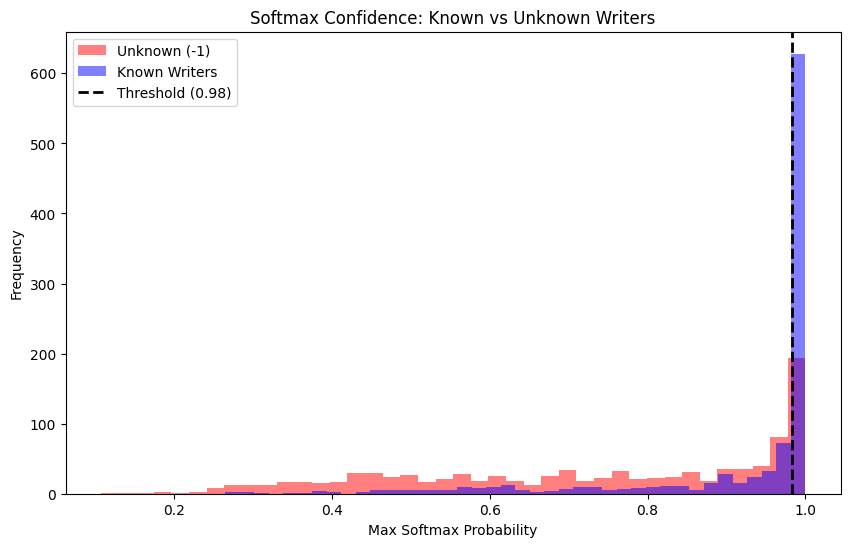

In [6]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ==========================================
# PASTE YOUR CLASSES HERE:
# 1. TestDataset class (we can use this to load images simply)
# 2. get_acgan_discriminator() function
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        if self.transform:
            image = self.transform(image)
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id

# ==========================================
# 2. THE AC-GAN DISCRIMINATOR
# ==========================================
def get_acgan_discriminator(device, num_classes=45):
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Identity() 
    
    class DualOutputConvNeXt(nn.Module):
        def __init__(self, base_model, in_features, classes):
            super().__init__()
            self.features = base_model
            self.adv_head = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
            self.class_head = nn.Linear(in_features, classes) 
            
        def forward(self, x):
            features = self.features(x)
            validity = self.adv_head(features)
            label_pred = self.class_head(features)
            return validity, label_pred

    return DualOutputConvNeXt(disc, num_ftrs, num_classes).to(device)

if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    MODEL_PATH = "best_acgan_discriminator.pth"
    MAPPING_PATH = "writer_mapping.csv"

    print("Loading data for Threshold Analysis...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # 1. Extract a sample of known and unknown writers
    unknown_df = full_df[full_df['writer_id'] == '-1'].sample(n=1000, random_state=42)
    known_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'] != 'nan')].sample(n=1000, random_state=42)
    eval_df = pd.concat([unknown_df, known_df]).reset_index(drop=True)
    
    # True labels: 0 for Unknown (-1), 1 for Known
    true_labels = (eval_df['writer_id'] != '-1').astype(int).values

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    eval_dataset = TestDataset(eval_df, img_dir=BASE_DIR, transform=transform)
    eval_loader = DataLoader(eval_dataset, batch_size=128, shuffle=False)

    print("Loading AC-GAN model...")
    mapping_df = pd.read_csv(MAPPING_PATH)
    NUM_CLASSES = len(mapping_df)
    
    disc = get_acgan_discriminator(DEVICE, num_classes=NUM_CLASSES)
    disc.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    disc.eval()

    max_softmax_scores = []

    print("Extracting Softmax probabilities...")
    with torch.no_grad():
        for images, _ in eval_loader:
            images = images.to(DEVICE)
            
            # Forward pass to get classification logits
            _, class_logits = disc(images)
            
            # Convert to probabilities
            probabilities = F.softmax(class_logits, dim=1)
            
            # Get the highest probability for each image
            max_probs, _ = torch.max(probabilities, dim=1)
            max_softmax_scores.extend(max_probs.cpu().numpy())

    max_softmax_scores = np.array(max_softmax_scores)

    # Calculate optimal threshold using Youden's J statistic
    fpr, tpr, thresholds = roc_curve(true_labels, max_softmax_scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"\n======================================")
    print(f"OPTIMAL DATA-DRIVEN THRESHOLD: {optimal_threshold:.4f}")
    print(f"======================================")

    # Optional: Plot the distribution to visually verify
    plt.figure(figsize=(10, 6))
    plt.hist(max_softmax_scores[true_labels == 0], bins=40, alpha=0.5, color='red', label='Unknown (-1)')
    plt.hist(max_softmax_scores[true_labels == 1], bins=40, alpha=0.5, color='blue', label='Known Writers')
    plt.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({optimal_threshold:.2f})')
    plt.title('Softmax Confidence: Known vs Unknown Writers')
    plt.xlabel('Max Softmax Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.savefig('softmax_threshold_analysis.png')
    print("Saved plot to 'softmax_threshold_analysis.png'")

In [9]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ==========================================
# 1. TEST DATASET CLASS
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        if self.transform:
            image = self.transform(image)
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id

# ==========================================
# 2. THE AC-GAN DISCRIMINATOR
# ==========================================
def get_acgan_discriminator(device, num_classes=45):
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Identity() 
    
    class DualOutputConvNeXt(nn.Module):
        def __init__(self, base_model, in_features, classes):
            super().__init__()
            self.features = base_model
            self.adv_head = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
            self.class_head = nn.Linear(in_features, classes) 
            
        def forward(self, x):
            features = self.features(x)
            validity = self.adv_head(features)
            label_pred = self.class_head(features)
            return validity, label_pred

    return DualOutputConvNeXt(disc, num_ftrs, num_classes).to(device)

# ==========================================
# 3. INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TEST_CSV = "myDataset/test.csv"
    BASE_DIR = "myDataset"
    MODEL_PATH = "best_acgan_discriminator.pth"
    MAPPING_PATH = "writer_mapping.csv"

    print("Loading test data and label mappings...")
    test_df = pd.read_csv(TEST_CSV)
    
    # Load the dictionary that maps integers (0-44) back to "Wxx" strings
    mapping_df = pd.read_csv(MAPPING_PATH)
    idx_to_writer = dict(zip(mapping_df['encoded_label'], mapping_df['writer_id']))
    NUM_CLASSES = len(idx_to_writer)

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    test_loader = DataLoader(TestDataset(test_df, BASE_DIR, transform), batch_size=128, shuffle=False)

    print("Loading Best AC-GAN Discriminator...")
    disc = get_acgan_discriminator(DEVICE, num_classes=NUM_CLASSES)
    disc.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    disc.eval()

    final_predictions = []
    
    # --- THE SOFTMAX THRESHOLD ---
    # Because we are using Softmax, 1.0 means 100% certainty. 
    # If the highest probability is below 0.60, it's likely an unknown writer.
    CONFIDENCE_THRESHOLD = 0.9828

    print("Evaluating Kaggle Test Set...")
    with torch.no_grad():
        for images, image_ids in test_loader:
            images = images.to(DEVICE)
            
            # Forward pass (we only care about the classification head now)
            _, class_logits = disc(images)
            
            # Convert raw logits to probabilities (0.0 to 1.0)
            probabilities = F.softmax(class_logits, dim=1)
            
            # Get the highest probability and its corresponding class index
            max_probs, predicted_indices = torch.max(probabilities, dim=1)
            
            max_probs = max_probs.cpu().numpy()
            predicted_indices = predicted_indices.cpu().numpy()
            
            for img_id, prob, idx in zip(image_ids, max_probs, predicted_indices):
                if prob < CONFIDENCE_THRESHOLD:
                    final_predictions.append({'image_id': img_id, 'writer_id': '-1'})
                else:
                    mapped_writer = idx_to_writer[idx]
                    final_predictions.append({'image_id': img_id, 'writer_id': mapped_writer})

    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! AC-GAN submission generated: submission_writer.csv")
    print(submission_df['writer_id'].value_counts().head(15))

Loading test data and label mappings...
Loading Best AC-GAN Discriminator...
Evaluating Kaggle Test Set...

SUCCESS! AC-GAN submission generated: submission_writer.csv
writer_id
-1     4845
W48     219
W42     122
W01      94
W12      73
W23      70
W37      55
W35      48
W43      41
W13      38
W14      33
W32      27
W15      26
W50      22
W24      22
Name: count, dtype: int64


In [10]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split

# ==========================================
# 1. DATASET & MAPPING
# ==========================================
class WriterDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
            
        label = self.data.loc[idx, 'encoded_label']
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 2. THE COLLABORATIVE RESIDUAL ARCHITECTURE
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=45):
        super().__init__()
        
        # --- A. SHARED TRUNK ---
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        # --- B. INDEPENDENT EXPERTS ---
        self.independent_experts = nn.Linear(in_features, num_classes)
        
        # --- C. CROSS-TALK RESIDUAL CONNECTION ---
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        
        raw_opinions = self.independent_experts(features)
        adjustments = self.cross_talk(raw_opinions)
        
        # The Final Output is the Residual combination
        final_scores = raw_opinions + adjustments
        return final_scores

# ==========================================
# 3. TRAINING AND VALIDATION LOOP
# ==========================================
if __name__ == "__main__":
    # --- HYPERPARAMETERS ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128 # Can be larger since there's no Generator!
    NUM_EPOCHS = 40
    LR = 0.0002
    BASE_DIR = "myDataset"
    
    print(f"Using device: {DEVICE}")

    # --- DATA PREP ---
    print("Loading and preparing data...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    
    # Drop -1 for training to force precise class boundaries
    full_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'].notna())].copy()
    
    unique_writers = sorted(full_df['writer_id'].unique())
    NUM_CLASSES = len(unique_writers)
    writer_to_idx = {writer: idx for idx, writer in enumerate(unique_writers)}
    full_df['encoded_label'] = full_df['writer_id'].map(writer_to_idx)
    
    pd.DataFrame(list(writer_to_idx.items()), columns=['writer_id', 'encoded_label']).to_csv('collab_writer_mapping.csv', index=False)

    train_df, val_df = train_test_split(full_df, test_size=0.15, stratify=full_df['encoded_label'], random_state=42)
    print(f"Train Set: {len(train_df)} images | Validation Set: {len(val_df)} images")

    # --- TRANSFORMS ---
    # Stronger augmentation helps the classifier generalize better
    train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomRotation(15), 
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    train_loader = DataLoader(WriterDataset(train_df, BASE_DIR, train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(WriterDataset(val_df, BASE_DIR, val_transform), batch_size=BATCH_SIZE, shuffle=False)

    # --- INIT MODEL, LOSS, OPTIMIZER ---
    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4) # AdamW helps prevent overfitting
    
    # Optional: Learning Rate Scheduler to fine-tune at the end
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

    best_val_acc = 0.0

    # --- THE LOOP ---
    print("\nStarting Collaborative Residual Training...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        # --- VALIDATION ---
        model.eval()
        correct = 0
        total = 0
        val_loss = 0.0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        val_acc = 100 * correct / total
        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # Step the scheduler based on validation accuracy
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_collaborative_model.pth')
            print(f" --> Saved new best model with Val Acc: {val_acc:.2f}%")

    print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

Using device: cuda
Loading and preparing data...
Train Set: 9180 images | Validation Set: 1620 images


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "



Starting Collaborative Residual Training...
Epoch [1/40] | Train Loss: 3.5137 | Val Loss: 2.9686 | Val Acc: 20.43%
 --> Saved new best model with Val Acc: 20.43%
Epoch [2/40] | Train Loss: 2.1922 | Val Loss: 1.4747 | Val Acc: 56.23%
 --> Saved new best model with Val Acc: 56.23%
Epoch [3/40] | Train Loss: 1.3025 | Val Loss: 1.1297 | Val Acc: 65.62%
 --> Saved new best model with Val Acc: 65.62%
Epoch [4/40] | Train Loss: 0.8781 | Val Loss: 0.8076 | Val Acc: 75.80%
 --> Saved new best model with Val Acc: 75.80%
Epoch [5/40] | Train Loss: 0.6321 | Val Loss: 0.6202 | Val Acc: 80.93%
 --> Saved new best model with Val Acc: 80.93%
Epoch [6/40] | Train Loss: 0.4787 | Val Loss: 0.5902 | Val Acc: 81.42%
 --> Saved new best model with Val Acc: 81.42%
Epoch [7/40] | Train Loss: 0.3792 | Val Loss: 0.4477 | Val Acc: 86.05%
 --> Saved new best model with Val Acc: 86.05%
Epoch [8/40] | Train Loss: 0.3046 | Val Loss: 0.4738 | Val Acc: 85.43%
Epoch [9/40] | Train Loss: 0.2541 | Val Loss: 0.4480 | Val

In [13]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ==========================================
# PASTE YOUR CLASSES HERE:
# 1. TestDataset class (we can use this to load images simply)
# 2. get_acgan_discriminator() function
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        if self.transform:
            image = self.transform(image)
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id

# ==========================================
# 2. THE AC-GAN DISCRIMINATOR
# ==========================================
def get_acgan_discriminator(device, num_classes=45):
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Identity() 
    
    class DualOutputConvNeXt(nn.Module):
        def __init__(self, base_model, in_features, classes):
            super().__init__()
            self.features = base_model
            self.adv_head = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
            self.class_head = nn.Linear(in_features, classes) 
            
        def forward(self, x):
            features = self.features(x)
            validity = self.adv_head(features)
            label_pred = self.class_head(features)
            return validity, label_pred

    return DualOutputConvNeXt(disc, num_ftrs, num_classes).to(device)
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    MODEL_PATH = "best_collaborative_model.pth"
    MAPPING_PATH = "collab_writer_mapping.csv"

    print("Loading data for Threshold Analysis...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # 1. Extract a sample of known and unknown writers
    unknown_df = full_df[full_df['writer_id'] == '-1'].sample(n=1000, random_state=42)
    known_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'] != 'nan')].sample(n=1000, random_state=42)
    eval_df = pd.concat([unknown_df, known_df]).reset_index(drop=True)
    
    # True labels: 0 for Unknown (-1), 1 for Known
    true_labels = (eval_df['writer_id'] != '-1').astype(int).values

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    eval_dataset = TestDataset(eval_df, img_dir=BASE_DIR, transform=transform)
    eval_loader = DataLoader(eval_dataset, batch_size=128, shuffle=False)

    print("Loading AC-GAN model...")
    mapping_df = pd.read_csv(MAPPING_PATH)
    NUM_CLASSES = len(mapping_df)
    
    disc = get_acgan_discriminator(DEVICE, num_classes=NUM_CLASSES)
    disc.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    disc.eval()

    max_softmax_scores = []

    print("Extracting Softmax probabilities...")
    with torch.no_grad():
        for images, _ in eval_loader:
            images = images.to(DEVICE)
            
            # Forward pass to get classification logits
            _, class_logits = disc(images)
            
            # Convert to probabilities
            probabilities = F.softmax(class_logits, dim=1)
            
            # Get the highest probability for each image
            max_probs, _ = torch.max(probabilities, dim=1)
            max_softmax_scores.extend(max_probs.cpu().numpy())

    max_softmax_scores = np.array(max_softmax_scores)

    # Calculate optimal threshold using Youden's J statistic
    fpr, tpr, thresholds = roc_curve(true_labels, max_softmax_scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"\n======================================")
    print(f"OPTIMAL DATA-DRIVEN THRESHOLD: {optimal_threshold:.4f}")
    print(f"======================================")

    # Optional: Plot the distribution to visually verify
    plt.figure(figsize=(10, 6))
    plt.hist(max_softmax_scores[true_labels == 0], bins=40, alpha=0.5, color='red', label='Unknown (-1)')
    plt.hist(max_softmax_scores[true_labels == 1], bins=40, alpha=0.5, color='blue', label='Known Writers')
    plt.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({optimal_threshold:.2f})')
    plt.title('Softmax Confidence: Known vs Unknown Writers')
    plt.xlabel('Max Softmax Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.savefig('softmax_threshold_analysis.png')
    print("Saved plot to 'softmax_threshold_analysis.png'")

Loading data for Threshold Analysis...
Loading AC-GAN model...


RuntimeError: Error(s) in loading state_dict for DualOutputConvNeXt:
	Missing key(s) in state_dict: "features.features.0.0.weight", "features.features.0.0.bias", "features.features.0.1.weight", "features.features.0.1.bias", "features.features.1.0.layer_scale", "features.features.1.0.block.0.weight", "features.features.1.0.block.0.bias", "features.features.1.0.block.2.weight", "features.features.1.0.block.2.bias", "features.features.1.0.block.3.weight", "features.features.1.0.block.3.bias", "features.features.1.0.block.5.weight", "features.features.1.0.block.5.bias", "features.features.1.1.layer_scale", "features.features.1.1.block.0.weight", "features.features.1.1.block.0.bias", "features.features.1.1.block.2.weight", "features.features.1.1.block.2.bias", "features.features.1.1.block.3.weight", "features.features.1.1.block.3.bias", "features.features.1.1.block.5.weight", "features.features.1.1.block.5.bias", "features.features.1.2.layer_scale", "features.features.1.2.block.0.weight", "

Loading data for Threshold Analysis...
Loading Collaborative model...
Extracting Softmax probabilities...

OPTIMAL DATA-DRIVEN THRESHOLD: 0.9998
Saved plot to 'collab_threshold_analysis.png'


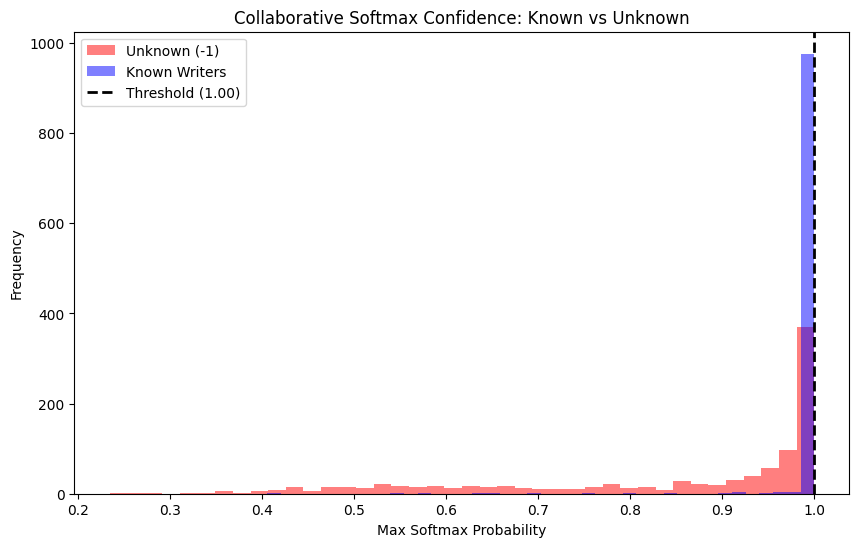

In [15]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ==========================================
# 1. TEST DATASET CLASS
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        if self.transform:
            image = self.transform(image)
        return image, self.data.loc[idx, 'image_id']

# ==========================================
# 2. THE COLLABORATIVE ARCHITECTURE
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=45):
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        self.independent_experts = nn.Linear(in_features, num_classes)
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        raw_opinions = self.independent_experts(features)
        adjustments = self.cross_talk(raw_opinions)
        return raw_opinions + adjustments

# ==========================================
# 3. THRESHOLD ANALYSIS
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    MODEL_PATH = "best_collaborative_model.pth"
    MAPPING_PATH = "collab_writer_mapping.csv"

    print("Loading data for Threshold Analysis...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Extract sample
    unknown_df = full_df[full_df['writer_id'] == '-1'].sample(n=1000, random_state=42)
    known_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'] != 'nan')].sample(n=1000, random_state=42)
    eval_df = pd.concat([unknown_df, known_df]).reset_index(drop=True)
    
    true_labels = (eval_df['writer_id'] != '-1').astype(int).values

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    eval_dataset = TestDataset(eval_df, img_dir=BASE_DIR, transform=transform)
    eval_loader = DataLoader(eval_dataset, batch_size=128, shuffle=False)

    print("Loading Collaborative model...")
    mapping_df = pd.read_csv(MAPPING_PATH)
    NUM_CLASSES = len(mapping_df)
    
    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    max_softmax_scores = []

    print("Extracting Softmax probabilities...")
    with torch.no_grad():
        for images, _ in eval_loader:
            images = images.to(DEVICE)
            
            # Forward pass (Only 1 output now!)
            raw_logits = model(images)
            
            # Convert to probabilities
            probabilities = F.softmax(raw_logits, dim=1)
            
            # Get the highest probability
            max_probs, _ = torch.max(probabilities, dim=1)
            max_softmax_scores.extend(max_probs.cpu().numpy())

    max_softmax_scores = np.array(max_softmax_scores)

    # Calculate optimal threshold
    fpr, tpr, thresholds = roc_curve(true_labels, max_softmax_scores)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    print(f"\n======================================")
    print(f"OPTIMAL DATA-DRIVEN THRESHOLD: {optimal_threshold:.4f}")
    print(f"======================================")

    # Save distribution plot
    plt.figure(figsize=(10, 6))
    plt.hist(max_softmax_scores[true_labels == 0], bins=40, alpha=0.5, color='red', label='Unknown (-1)')
    plt.hist(max_softmax_scores[true_labels == 1], bins=40, alpha=0.5, color='blue', label='Known Writers')
    plt.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({optimal_threshold:.2f})')
    plt.title('Collaborative Softmax Confidence: Known vs Unknown')
    plt.xlabel('Max Softmax Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.savefig('collab_threshold_analysis.png')
    print("Saved plot to 'collab_threshold_analysis.png'")

In [17]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ==========================================
# 1. TEST DATASET CLASS
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L') 
        if self.transform:
            image = self.transform(image)
        image_id = self.data.loc[idx, 'image_id']
        return image, image_id

# ==========================================
# 2. THE COLLABORATIVE ARCHITECTURE
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=45):
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        self.independent_experts = nn.Linear(in_features, num_classes)
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        raw_opinions = self.independent_experts(features)
        adjustments = self.cross_talk(raw_opinions)
        return raw_opinions + adjustments

# ==========================================
# 3. KAGGLE INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TEST_CSV = "myDataset/test.csv"
    BASE_DIR = "myDataset"
    MODEL_PATH = "best_collaborative_model.pth"
    MAPPING_PATH = "collab_writer_mapping.csv"

    print("Loading test data and label mappings...")
    test_df = pd.read_csv(TEST_CSV)
    
    mapping_df = pd.read_csv(MAPPING_PATH)
    idx_to_writer = dict(zip(mapping_df['encoded_label'], mapping_df['writer_id']))
    NUM_CLASSES = len(idx_to_writer)

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    test_loader = DataLoader(TestDataset(test_df, BASE_DIR, transform), batch_size=128, shuffle=False)

    print("Loading Best Collaborative Classifier...")
    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    final_predictions = []
    
    # ==========================================================
    # --- PUT YOUR NEW DATA-DRIVEN THRESHOLD HERE ---
    # ==========================================================
    CONFIDENCE_THRESHOLD = 0.85 # <-- Replace with the new calculation!

    print("Evaluating Kaggle Test Set...")
    with torch.no_grad():
        for images, image_ids in test_loader:
            images = images.to(DEVICE)
            
            # 1. Get raw residual scores
            raw_scores = model(images)
            
            # 2. Convert to probabilities
            probabilities = F.softmax(raw_scores, dim=1)
            
            # 3. Find highest probability
            max_probs, predicted_indices = torch.max(probabilities, dim=1)
            
            max_probs = max_probs.cpu().numpy()
            predicted_indices = predicted_indices.cpu().numpy()
            
            for img_id, prob, idx in zip(image_ids, max_probs, predicted_indices):
                if prob < CONFIDENCE_THRESHOLD:
                    final_predictions.append({'image_id': img_id, 'writer_id': '-1'})
                else:
                    mapped_writer = idx_to_writer[idx]
                    final_predictions.append({'image_id': img_id, 'writer_id': mapped_writer})

    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! Collaborative submission generated: submission_writer.csv")
    print(submission_df['writer_id'].value_counts().head(10))

Loading test data and label mappings...
Loading Best Collaborative Classifier...
Evaluating Kaggle Test Set...

SUCCESS! Collaborative submission generated: submission_writer.csv
writer_id
-1     2129
W48     437
W12     249
W49     224
W07     188
W23     159
W42     148
W14     138
W41     138
W17     135
Name: count, dtype: int64


In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ==========================================
# 1. FILTERED DATASET CLASS
# ==========================================
class SingleWriterDataset(Dataset):
    def __init__(self, dataframe, img_dir, target_writer, transform=None):
        # FILTER: Only keep the images for the specific writer we are training!
        self.data = dataframe[dataframe['writer_id'] == target_writer].reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        print(f"Loaded {len(self.data)} training images for {target_writer}.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image

# ==========================================
# 2. GENERATOR (ENCODER-DECODER)
# ==========================================
class RedrawGenerator(nn.Module):
    def __init__(self, channels=1, features=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 4, features * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(features, channels, 4, 2, 1),
            nn.Tanh() 
        )

    def forward(self, x):
        bottleneck = self.encoder(x)
        return self.decoder(bottleneck)

# ==========================================
# 3. DISCRIMINATOR (CONVNEXT-TINY)
# ==========================================
def get_binary_convnext(device):
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    disc = models.convnext_tiny(weights=weights)
    
    # Modify stem for 1-channel Grayscale
    original_stem = disc.features[0][0]
    disc.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                    kernel_size=original_stem.kernel_size, stride=original_stem.stride)
    
    # Binary Classification Head (Real vs. Fake Redraw)
    num_ftrs = disc.classifier[2].in_features
    disc.classifier[2] = nn.Sequential(
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    return disc.to(device)
# ==========================================
# 4. SEQUENTIAL TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 64
    NUM_EPOCHS = 100
    LR = 0.0002
    L1_LAMBDA = 100 
    BASE_DIR = "myDataset"
    SAVE_DIR = "saved_autoencoders"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # --- DATA PREP ---
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    
    # Get all unique writers, excluding the '-1' strangers
    unique_writers = [w for w in full_df['writer_id'].unique() if w != '-1' and pd.notna(w)]
    unique_writers.sort()

    train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    # --- THE MASTER LOOP ---
    for TARGET_WRITER in unique_writers:
        print(f"\n{'='*50}")
        print(f"--- Training Redraw GAN for {TARGET_WRITER} ---")
        print(f"{'='*50}")

        dataset = SingleWriterDataset(full_df, BASE_DIR, TARGET_WRITER, train_transform)
        
        # Skip if a writer has too few images to form a batch
        if len(dataset) < BATCH_SIZE:
            print(f"Skipping {TARGET_WRITER} - not enough data for batch size.")
            continue
            
        train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

        # RE-INITIALIZE MODELS FOR EACH WRITER
        gen = RedrawGenerator().to(DEVICE)
        disc = get_binary_convnext(DEVICE)

        criterion_adv = nn.BCELoss()
        criterion_pixel = nn.L1Loss() 
        
        opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(0.5, 0.999))
        opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(0.5, 0.999))

        for epoch in range(NUM_EPOCHS):
            loss_d_epoch = 0.0
            loss_g_epoch = 0.0
            
            for real_imgs in train_loader:
                real_imgs = real_imgs.to(DEVICE)
                batch_size = real_imgs.size(0)

                valid_target = torch.ones(batch_size, 1, device=DEVICE)
                fake_target = torch.zeros(batch_size, 1, device=DEVICE)

                # 1. Train Discriminator
                opt_disc.zero_grad()
                d_real_loss = criterion_adv(disc(real_imgs), valid_target)
                
                redrawn_imgs = gen(real_imgs)
                d_fake_loss = criterion_adv(disc(redrawn_imgs.detach()), fake_target)
                
                d_loss = (d_real_loss + d_fake_loss) / 2
                d_loss.backward()
                opt_disc.step()

                # 2. Train Generator
                opt_gen.zero_grad()
                g_adv_loss = criterion_adv(disc(redrawn_imgs), valid_target)
                g_pixel_loss = criterion_pixel(redrawn_imgs, real_imgs)
                
                g_loss = g_adv_loss + (L1_LAMBDA * g_pixel_loss)
                g_loss.backward()
                opt_gen.step()
                
                loss_d_epoch += d_loss.item()
                loss_g_epoch += g_loss.item()

            if (epoch + 1) % 10 == 0:
                print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] | D Loss: {loss_d_epoch/len(train_loader):.4f} | G Loss: {loss_g_epoch/len(train_loader):.4f}")

        # SAVE THE GENERATOR FOR THIS SPECIFIC WRITER
        save_path = os.path.join(SAVE_DIR, f"generator_{TARGET_WRITER}.pth")
        torch.save(gen.state_dict(), save_path)
        print(f"Saved Generator to {save_path}")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.1
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.



--- Training Redraw GAN for W01 ---
Loaded 250 training images for W01.


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025831440/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


  Epoch [10/100] | D Loss: 0.0015 | G Loss: 34.4375
  Epoch [20/100] | D Loss: 0.0002 | G Loss: 30.1899
  Epoch [30/100] | D Loss: 0.0001 | G Loss: 28.1756
  Epoch [40/100] | D Loss: 0.5801 | G Loss: 18.0976
  Epoch [50/100] | D Loss: 0.0003 | G Loss: 24.3334
  Epoch [60/100] | D Loss: 0.0002 | G Loss: 25.2430
  Epoch [70/100] | D Loss: 0.0001 | G Loss: 25.4624
  Epoch [80/100] | D Loss: 0.0001 | G Loss: 25.4364
  Epoch [90/100] | D Loss: 0.0000 | G Loss: 25.4317
  Epoch [100/100] | D Loss: 0.0001 | G Loss: 25.6628
Saved Generator to saved_autoencoders/generator_W01.pth

--- Training Redraw GAN for W03 ---
Loaded 250 training images for W03.
  Epoch [10/100] | D Loss: 0.0007 | G Loss: 39.0429
  Epoch [20/100] | D Loss: 0.0002 | G Loss: 36.7129
  Epoch [30/100] | D Loss: 0.0001 | G Loss: 35.7476
  Epoch [40/100] | D Loss: 0.0001 | G Loss: 33.6933
  Epoch [50/100] | D Loss: 0.0000 | G Loss: 33.7436
  Epoch [60/100] | D Loss: 0.0000 | G Loss: 33.7017
  Epoch [70/100] | D Loss: 0.0000 | G 

Preparing balanced evaluation dataset...
Evaluating 44 models against all classes...

Plotting Heatmap...
SUCCESS! Heatmap saved as 'reconstruction_heatmap.png'.


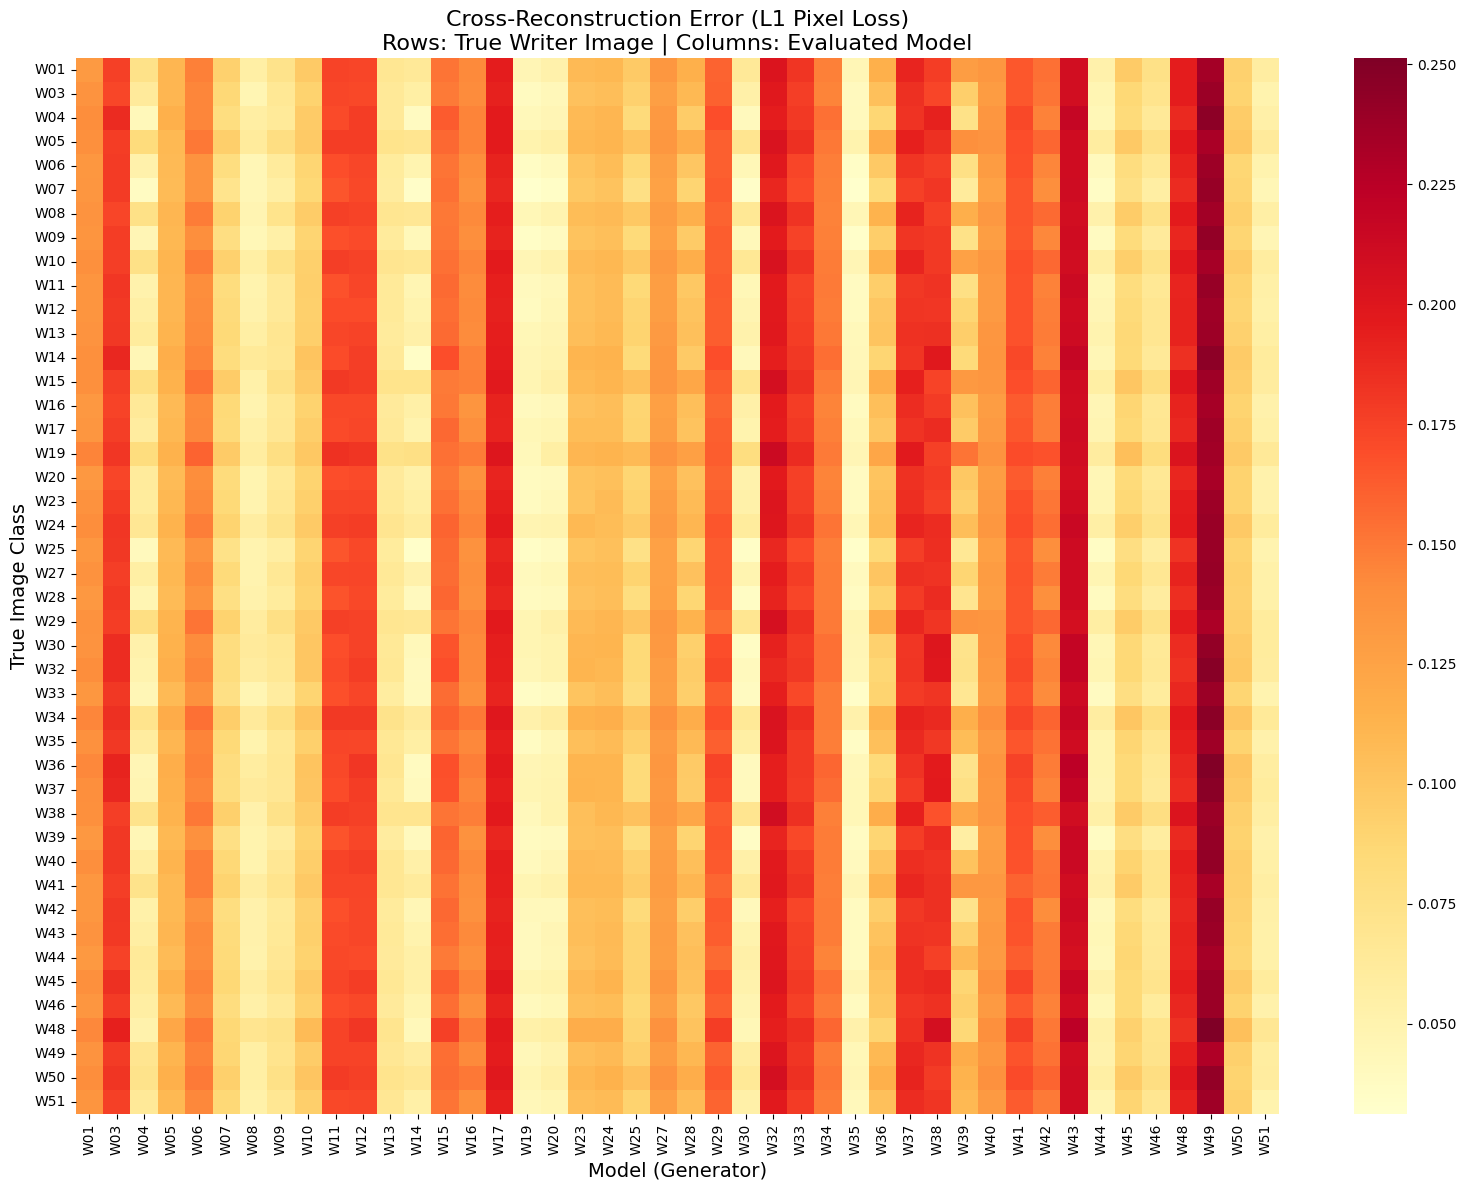

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. EVALUATION DATASET
# ==========================================
class EvalDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        writer_id = self.data.loc[idx, 'writer_id']
        return image, writer_id

# ==========================================
# 2. GENERATOR (MUST MATCH TRAINING SCRIPT)
# ==========================================
class RedrawGenerator(nn.Module):
    def __init__(self, channels=1, features=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features * 4, features * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(features, channels, 4, 2, 1),
            nn.Tanh() 
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ==========================================
# 3. HEATMAP GENERATION LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    SAVE_DIR = "saved_autoencoders"
    IMAGES_PER_WRITER = 20 # Keep it small for a fast evaluation
    
    print("Preparing balanced evaluation dataset...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    
    # Filter out unknown strangers for this specific matrix
    known_df = full_df[(full_df['writer_id'] != '-1') & (full_df['writer_id'].notna())]
    
    # Sample exactly N images per writer
    eval_df = known_df.groupby('writer_id').sample(n=IMAGES_PER_WRITER, random_state=42, replace=True)
    unique_writers = sorted(eval_df['writer_id'].unique())
    
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    
    # Batch size can be large here since no gradients are stored
    eval_loader = DataLoader(EvalDataset(eval_df, BASE_DIR, transform), batch_size=128, shuffle=False)
    
    # Initialize the results matrix: Rows = True Images, Cols = Models
    results_matrix = pd.DataFrame(index=unique_writers, columns=unique_writers, data=0.0)
    
    criterion_pixel = nn.L1Loss(reduction='none') # 'none' so we can average per-image

    gen = RedrawGenerator().to(DEVICE)
    gen.eval()

    print(f"Evaluating {len(unique_writers)} models against all classes...")
    
    with torch.no_grad():
        for model_writer in unique_writers:
            model_path = os.path.join(SAVE_DIR, f"generator_{model_writer}.pth")
            
            if not os.path.exists(model_path):
                print(f"  [!] Missing model for {model_writer}, skipping column.")
                continue
                
            # Load specific writer's weights
            gen.load_state_dict(torch.load(model_path, map_location=DEVICE))
            
            # Dictionary to track cumulative loss and count per true writer class
            class_loss_sum = {w: 0.0 for w in unique_writers}
            class_count = {w: 0 for w in unique_writers}
            
            for images, true_writers in eval_loader:
                images = images.to(DEVICE)
                redrawn = gen(images)
                
                # Calculate pixel error for each image in the batch (Batch, Channels, H, W)
                # Mean across C, H, W dimensions to get a single error score per image
                errors = criterion_pixel(redrawn, images).mean(dim=[1, 2, 3]).cpu().numpy()
                
                for err, t_writer in zip(errors, true_writers):
                    class_loss_sum[t_writer] += err
                    class_count[t_writer] += 1
                    
            # Average the loss and store it in the matrix column
            for t_writer in unique_writers:
                if class_count[t_writer] > 0:
                    avg_error = class_loss_sum[t_writer] / class_count[t_writer]
                    results_matrix.loc[t_writer, model_writer] = avg_error

    # ==========================================
    # 4. PLOTTING THE HEATMAP
    # ==========================================
    print("\nPlotting Heatmap...")
    plt.figure(figsize=(16, 12))
    
    # We use a reversed colormap because LOW error is GOOD (we want the diagonal to be dark/distinct)
    sns.heatmap(results_matrix.astype(float), cmap="YlOrRd", annot=False, fmt=".3f")
    
    plt.title("Cross-Reconstruction Error (L1 Pixel Loss)\nRows: True Writer Image | Columns: Evaluated Model", fontsize=16)
    plt.xlabel("Model (Generator)", fontsize=14)
    plt.ylabel("True Image Class", fontsize=14)
    plt.tight_layout()
    plt.savefig("reconstruction_heatmap.png", dpi=300)
    print("SUCCESS! Heatmap saved as 'reconstruction_heatmap.png'.")

In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from scipy.spatial.distance import cdist

# ==========================================
# 1. DATASETS
# ==========================================
class SimpleDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, is_test=False):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
            
        if self.is_test:
            return image, self.data.loc[idx, 'image_id']
        else:
            return image, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. COLLABORATIVE ARCHITECTURE (Feature Extractor)
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=45):
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        
        # We don't need the rest of the layers for feature extraction!

    def extract_features(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        return self.flatten(features)

# ==========================================
# 3. CENTROID DISTANCE INFERENCE
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    TEST_CSV = "myDataset/test.csv"
    MODEL_PATH = "best_collaborative_model.pth"
    MAPPING_PATH = "collab_writer_mapping.csv"

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    print("Loading 88.7% Collaborative Model for Feature Extraction...")
    mapping_df = pd.read_csv(MAPPING_PATH)
    NUM_CLASSES = len(mapping_df)
    
    # Load the model, but we will only use the `.extract_features()` method
    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE), strict=False)
    model.eval()

    # --- STEP 1: CALCULATE CLASS CENTROIDS ---
    print("\nCalculating Class Centroids from Training Data...")
    df1 = pd.read_csv('train.csv')
    df2 = pd.read_csv('additional_train.csv')
    full_train = pd.concat([df1, df2], ignore_index=True)
    known_train = full_train[(full_train['writer_id'] != '-1') & (full_train['writer_id'].notna())]
    
    train_loader = DataLoader(SimpleDataset(known_train, BASE_DIR, transform), batch_size=128, shuffle=False)
    
    class_features = {writer: [] for writer in known_train['writer_id'].unique()}
    
    with torch.no_grad():
        for images, writers in train_loader:
            images = images.to(DEVICE)
            features = model.extract_features(images).cpu().numpy()
            for feat, writer in zip(features, writers):
                class_features[writer].append(feat)
                
    # Average the features to create 1 single prototype vector per writer
    centroids = {}
    for writer, feats in class_features.items():
        centroids[writer] = np.mean(feats, axis=0)
        
    centroid_matrix = np.array(list(centroids.values()))
    writer_labels = list(centroids.keys())

    # --- STEP 2: EVALUATE KAGGLE TEST SET ---
    print("\nEvaluating Kaggle Test Set via Cosine Distance...")
    test_df = pd.read_csv(TEST_CSV)
    test_loader = DataLoader(SimpleDataset(test_df, BASE_DIR, transform, is_test=True), batch_size=128, shuffle=False)

    final_predictions = []
    
    # The Threshold: Cosine distance ranges from 0.0 (identical) to 1.0 (orthogonal) to 2.0 (opposite).
    # If a test image is further than this distance from the CLOSEST centroid, it's a stranger.
    # 0.45 is a highly standard starting point for ConvNeXt feature spaces.
    MAX_DISTANCE_THRESHOLD = 0.45 

    with torch.no_grad():
        for images, img_ids in test_loader:
            images = images.to(DEVICE)
            test_features = model.extract_features(images).cpu().numpy()
            
            # Calculate Cosine Distance between the test images and all 45 Centroids
            distances = cdist(test_features, centroid_matrix, metric='cosine')
            
            for i, img_id in enumerate(img_ids):
                min_dist = np.min(distances[i])
                closest_idx = np.argmin(distances[i])
                
                if min_dist > MAX_DISTANCE_THRESHOLD:
                    final_predictions.append({'image_id': img_id, 'writer_id': '-1'})
                else:
                    final_predictions.append({'image_id': img_id, 'writer_id': writer_labels[closest_idx]})

    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! Distance-based submission generated: submission_writer.csv")
    print(submission_df['writer_id'].value_counts().head(10))

Loading 88.7% Collaborative Model for Feature Extraction...

Calculating Class Centroids from Training Data...

Evaluating Kaggle Test Set via Cosine Distance...

SUCCESS! Distance-based submission generated: submission_writer.csv
writer_id
-1     2777
W48     365
W14     187
W49     173
W32     162
W37     136
W12     133
W36     127
W42     127
W23     114
Name: count, dtype: int64


In [6]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==========================================
# 1. DATASET
# ==========================================
class WriterDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label = self.data.loc[idx, 'encoded_label']
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 2. THE COLLABORATIVE ARCHITECTURE
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=46): # NOW 46 CLASSES!
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        self.independent_experts = nn.Linear(in_features, num_classes)
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        raw_opinions = self.independent_experts(features)
        adjustments = self.cross_talk(raw_opinions)
        return raw_opinions + adjustments

# ==========================================
# 3. TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128 
    NUM_EPOCHS = 40
    LR = 0.0002
    BASE_DIR = "myDataset"
    
    print("Loading and preparing 46-Class data...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    
    # CRITICAL FIX: We no longer drop '-1'. We make sure it's read as a string.
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Create the 46-class mapping
    unique_writers = sorted(full_df['writer_id'].unique())
    NUM_CLASSES = len(unique_writers)
    print(f"Total Unique Classes to Predict: {NUM_CLASSES}")
    
    writer_to_idx = {writer: idx for idx, writer in enumerate(unique_writers)}
    full_df['encoded_label'] = full_df['writer_id'].map(writer_to_idx)
    
    # Save mapping for Kaggle inference
    pd.DataFrame(list(writer_to_idx.items()), columns=['writer_id', 'encoded_label']).to_csv('mapping_46_class.csv', index=False)

    train_df, val_df = train_test_split(full_df, test_size=0.15, stratify=full_df['encoded_label'], random_state=42)
    print(f"Train Set: {len(train_df)} | Validation Set: {len(val_df)}")

    train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomRotation(15), 
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    train_loader = DataLoader(WriterDataset(train_df, BASE_DIR, train_transform), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(WriterDataset(val_df, BASE_DIR, val_transform), batch_size=BATCH_SIZE, shuffle=False)

    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    
    # We use class weights to handle the fact that '-1' might have way more images than W14
    class_counts = full_df['encoded_label'].value_counts().sort_index().values
    weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
    weights = weights / weights.sum() * NUM_CLASSES 
    criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

    best_val_acc = 0.0

    print("\nStarting 46-Class Training...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}] Training"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        val_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
        scheduler.step(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_46class_model.pth')

    print(f"\nTraining Complete! Best 46-Class Val Acc: {best_val_acc:.2f}%")

Loading and preparing 46-Class data...
Total Unique Classes to Predict: 45
Train Set: 34212 | Validation Set: 6038


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "



Starting 46-Class Training...


Epoch [1/40] Training: 100%|██████████████████| 268/268 [03:14<00:00,  1.38it/s]


Epoch [1/40] | Train Loss: 2.6491 | Val Acc: 40.56%


...

Epoch [38/40] | Train Loss: 0.0092 | Val Acc: 89.81%


Epoch [39/40] Training: 100%|█████████████████| 268/268 [00:48<00:00,  5.56it/s]


Epoch [39/40] | Train Loss: 0.0065 | Val Acc: 89.85%


Epoch [40/40] Training: 100%|█████████████████| 268/268 [00:48<00:00,  5.55it/s]


Epoch [40/40] | Train Loss: 0.0051 | Val Acc: 90.16%

Training Complete! Best 46-Class Val Acc: 90.16%


In [7]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# ==========================================
# 1. TEST DATASET
# ==========================================
class TestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, self.data.loc[idx, 'image_id']

# ==========================================
# 2. COLLABORATIVE ARCHITECTURE
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=46): # Match the 46 classes!
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        self.independent_experts = nn.Linear(in_features, num_classes)
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        raw_opinions = self.independent_experts(features)
        adjustments = self.cross_talk(raw_opinions)
        return raw_opinions + adjustments

# ==========================================
# 3. KAGGLE INFERENCE
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    TEST_CSV = "myDataset/test.csv"
    MODEL_PATH = "best_46class_model.pth"
    MAPPING_PATH = "mapping_46_class.csv"

    print("Loading Class Mappings...")
    mapping_df = pd.read_csv(MAPPING_PATH)
    # Ensure writer_id is treated as a string so '-1' stays intact
    mapping_df['writer_id'] = mapping_df['writer_id'].astype(str)
    
    idx_to_writer = dict(zip(mapping_df['encoded_label'], mapping_df['writer_id']))
    NUM_CLASSES = len(idx_to_writer)

    transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    print("Loading Kaggle Test Data...")
    test_df = pd.read_csv(TEST_CSV)
    test_loader = DataLoader(TestDataset(test_df, BASE_DIR, transform), batch_size=128, shuffle=False)

    print("Loading 90.16% Collaborative Model...")
    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    final_predictions = []

    print("Generating Predictions (Pure Argmax)...")
    with torch.no_grad():
        for images, img_ids in test_loader:
            images = images.to(DEVICE)
            
            # Forward pass
            outputs = model(images)
            
            # Pure Argmax: Whatever the network is most confident in wins!
            _, predicted_indices = torch.max(outputs, 1)
            predicted_indices = predicted_indices.cpu().numpy()
            
            for img_id, idx in zip(img_ids, predicted_indices):
                mapped_writer = idx_to_writer[idx]
                final_predictions.append({'image_id': img_id, 'writer_id': mapped_writer})

    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_writer.csv", index=False)
    
    print("\nSUCCESS! 46-Class Submission Generated: submission_writer.csv")
    print("\nTop 10 Predicted Classes (Preview):")
    print(submission_df['writer_id'].value_counts().head(10))

Loading Class Mappings...
Loading Kaggle Test Data...
Loading 90.16% Collaborative Model...
Generating Predictions (Pure Argmax)...

SUCCESS! 46-Class Submission Generated: submission_writer.csv

Top 10 Predicted Classes (Preview):
writer_id
-1     1210
W23     351
W12     338
W48     311
W42     266
W41     265
W49     228
W01     210
W45     202
W14     188
Name: count, dtype: int64


Saved 'pressure_map_demo.png'. Open it and look at the stroke cores!


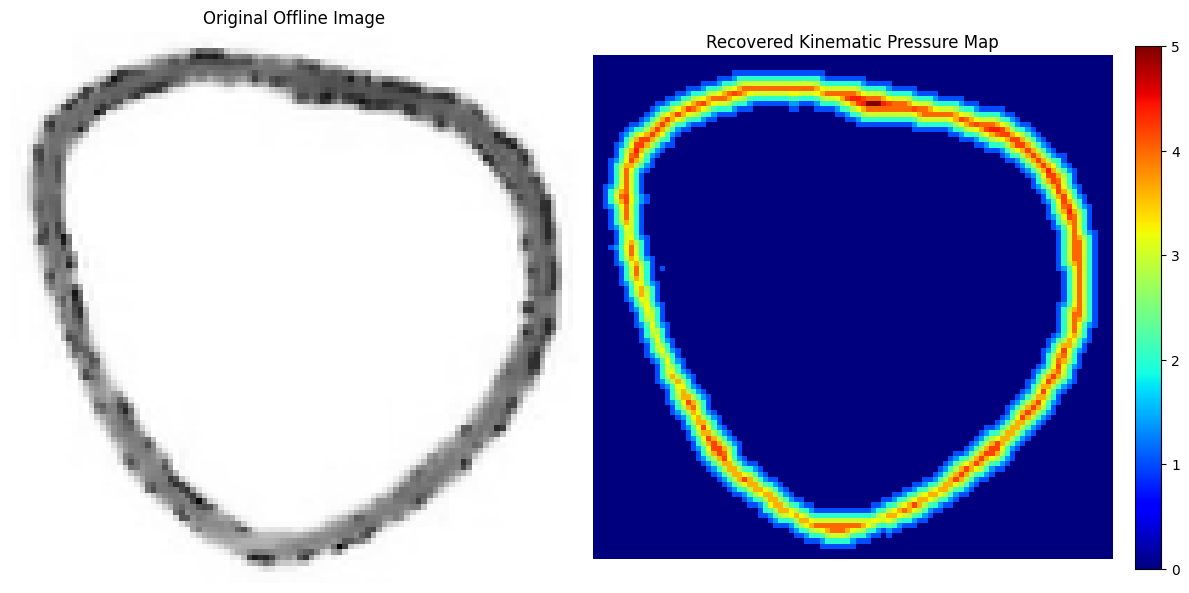

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_pressure_map(image_path):
    # 1. Load as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # 2. Invert so ink is white (255) and background is black (0)
    inverted = cv2.bitwise_not(img)
    
    # 3. Threshold to pure binary to remove gray anti-aliasing edges
    _, binary = cv2.threshold(inverted, 10, 255, cv2.THRESH_BINARY)
    
    # 4. THE MAGIC: Calculate the Distance Transform
    # This assigns a value to every pixel based on how far it is from the edge of the stroke
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original Offline Image')
    axes[0].axis('off')
    
    # Display the distance transform as a heat map (Jet colormap highlights the "core" pressure)
    im = axes[1].imshow(dist_transform, cmap='jet')
    axes[1].set_title('Recovered Kinematic Pressure Map')
    axes[1].axis('off')
    
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig('pressure_map_demo.png', dpi=300)
    print("Saved 'pressure_map_demo.png'. Open it and look at the stroke cores!")

# Replace with the path to ANY of your training images
visualize_pressure_map("myDataset/images/00001.png")

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import concurrent.futures
from tqdm import tqdm

BASE_DIR = "myDataset"
NUM_CORES = 8  # Maxing out your available CPU cores

def extract_biometric_fingerprint(row_data):
    """
    Worker function to process a single image.
    Takes a tuple of (index, image_path, writer_id) to easily track results.
    """
    idx, img_subpath, writer_id = row_data
    img_path = os.path.join(BASE_DIR, img_subpath)
    
    # Read image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None # Skip corrupted/missing files
        
    inverted = cv2.bitwise_not(img)
    
    # FEATURE 1: Intensity Histogram (How hard did they press?)
    # Only look at pixels that are actually ink (value > 10)
    ink_pixels = inverted[inverted > 10]
    if len(ink_pixels) == 0:
        return None
        
    # Create a 20-bin histogram of ink darkness, normalized so it sums to 1.0
    intensity_hist, _ = np.histogram(ink_pixels, bins=20, range=(10, 255), density=True)
    
    # FEATURE 2: Stroke Width Histogram (Distance Transform)
    _, binary = cv2.threshold(inverted, 10, 255, cv2.THRESH_BINARY)
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    
    # Only look at the interior of the strokes
    thickness_values = dist_transform[dist_transform > 0]
    
    # Create a 20-bin histogram of stroke thickness, normalized
    # (Range 0.1 to 15.0 pixels thick covers almost all 64x64 pen strokes)
    width_hist, _ = np.histogram(thickness_values, bins=20, range=(0.1, 15.0), density=True)
    
    # Combine into a single 40-dimensional feature vector
    fingerprint = np.concatenate([intensity_hist, width_hist])
    
    return {
        'image_id': img_subpath.split('/')[-1].split('.')[0], # Extract ID from filename
        'writer_id': writer_id,
        'fingerprint': fingerprint
    }

if __name__ == "__main__":
    print("Loading dataframes...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    
    # Clean the data (Drop NaNs)
    full_df = full_df.dropna(subset=['image_path', 'writer_id'])
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Prepare data for the multiprocessing pool
    row_tuples = [(idx, row['image_path'], row['writer_id']) for idx, row in full_df.iterrows()]
    
    print(f"Starting Multi-Core Extraction on {len(row_tuples)} images using {NUM_CORES} cores...")
    
    results = []
    
    # The Multi-Core Engine
    with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
        # Map the worker function across all rows, wrapped in TQDM for a progress bar
        for res in tqdm(executor.map(extract_biometric_fingerprint, row_tuples), total=len(row_tuples), desc="Extracting"):
            if res is not None:
                results.append(res)
                
    print("\nExtraction Complete. Formatting dataset...")
    
    # Convert results into a clean Machine Learning DataFrame
    extracted_df = pd.DataFrame(results)
    
    # Expand the 40-dimensional array into 40 separate columns (f_0 to f_39)
    fingerprint_columns = pd.DataFrame(extracted_df['fingerprint'].to_list(), columns=[f'f_{i}' for i in range(40)])
    
    final_ml_df = pd.concat([extracted_df[['image_id', 'writer_id']], fingerprint_columns], axis=1)
    
    # Save the physical features to a new CSV
    final_ml_df.to_csv("biometric_features.csv", index=False)
    print("SUCCESS! Saved physical features to 'biometric_features.csv'")
    print(f"Final Dataset Shape: {final_ml_df.shape}")

Loading dataframes...
Starting Multi-Core Extraction on 40250 images using 8 cores...


Extracting: 100%|███████████████████████| 40250/40250 [00:35<00:00, 1121.93it/s]



Extraction Complete. Formatting dataset...
SUCCESS! Saved physical features to 'biometric_features.csv'
Final Dataset Shape: (40250, 42)


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# 1. Load the Biometric Data
print("Loading Kinematic Biometric Features...")
df = pd.read_csv("biometric_features.csv")

# Ensure writer_id is a string (to handle '-1' properly)
df['writer_id'] = df['writer_id'].astype(str)

# 2. Separate Features (X) and Labels (y)
# The features are the columns f_0 through f_39
feature_cols = [f'f_{i}' for i in range(40)]
X = df[feature_cols].values
y = df['writer_id'].values

# 3. Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape[0]} samples")
print(f"Validation Data: {X_val.shape[0]} samples")

# 4. Train the Random Forest
# We use 500 trees and balanced class weights to heavily penalize missing the '-1' strangers
print("\nTraining Biometric Random Forest (This will be fast!)...")
rf_model = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Evaluate
print("\nEvaluating on Validation Set...")
y_pred = rf_model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"======================================")
print(f"KINEMATIC VALIDATION ACCURACY: {acc * 100:.2f}%")
print(f"======================================")

# Show detailed stats specifically for the '-1' class
report = classification_report(y_val, y_pred, output_dict=True)
if '-1' in report:
    print(f"\nPerformance on identifying Strangers ('-1'):")
    print(f"Precision: {report['-1']['precision']:.4f} (When it guessed -1, how often was it right?)")
    print(f"Recall:    {report['-1']['recall']:.4f} (Out of all true -1s, how many did it catch?)")

# 6. Save the model
joblib.dump(rf_model, "biometric_rf_model.pkl")
print("\nSaved model to 'biometric_rf_model.pkl'")

Loading Kinematic Biometric Features...
Training Data: 34212 samples
Validation Data: 6038 samples

Training Biometric Random Forest (This will be fast!)...

Evaluating on Validation Set...
KINEMATIC VALIDATION ACCURACY: 39.72%

Performance on identifying Strangers ('-1'):
Precision: 0.2791 (When it guessed -1, how often was it right?)
Recall:    0.7786 (Out of all true -1s, how many did it catch?)

Saved model to 'biometric_rf_model.pkl'


In [6]:
import os
import cv2
import pandas as pd
import numpy as np
import joblib
import concurrent.futures
from tqdm import tqdm

BASE_DIR = "myDataset"
TEST_CSV = "myDataset/test.csv"
NUM_CORES = 8

# ==========================================
# 1. BIOMETRIC EXTRACTOR
# ==========================================
def process_test_image(row_data):
    """Worker function to process a single test image."""
    img_id, img_subpath = row_data
    img_path = os.path.join(BASE_DIR, img_subpath)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Fallback for corrupted images
    if img is None: 
        return img_id, np.zeros(40) 
        
    inverted = cv2.bitwise_not(img)
    ink_pixels = inverted[inverted > 10]
    
    if len(ink_pixels) == 0: 
        return img_id, np.zeros(40)
        
    # Intensity Feature
    intensity_hist, _ = np.histogram(ink_pixels, bins=20, range=(10, 255), density=True)
    
    # Thickness Feature
    _, binary = cv2.threshold(inverted, 10, 255, cv2.THRESH_BINARY)
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    thickness_values = dist_transform[dist_transform > 0]
    
    if len(thickness_values) == 0:
        width_hist = np.zeros(20)
    else:
        width_hist, _ = np.histogram(thickness_values, bins=20, range=(0.1, 15.0), density=True)
    
    fingerprint = np.concatenate([intensity_hist, width_hist])
    return img_id, fingerprint

# ==========================================
# 2. INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    print("Loading Kinematic Random Forest...")
    rf_model = joblib.load("biometric_rf_model.pkl")
    
    print("Loading Kaggle Test Data...")
    test_df = pd.read_csv(TEST_CSV)
    
    row_tuples = [(row['image_id'], row['image_path']) for _, row in test_df.iterrows()]
    extracted_features = []
    
    print(f"Extracting features using {NUM_CORES} cores...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
        for result in tqdm(executor.map(process_test_image, row_tuples), total=len(row_tuples)):
            extracted_features.append(result)
            
    # Unpack results
    image_ids = [res[0] for res in extracted_features]
    X_test = np.array([res[1] for res in extracted_features])
    
    print("\nGenerating Predictions...")
    predictions = rf_model.predict(X_test)
    
    final_predictions = [{'image_id': img_id, 'writer_id': str(pred)} for img_id, pred in zip(image_ids, predictions)]
    
    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_rf_standalone.csv", index=False)
    
    print("\nSUCCESS! Standalone RF Submission Generated: submission_rf_standalone.csv")
    print("\nTop Predicted Classes (Notice how many '-1's it caught!):")
    print(submission_df['writer_id'].value_counts().head(10))

Loading Kinematic Random Forest...
Loading Kaggle Test Data...
Extracting features using 8 cores...


100%|██████████████████████████████████████| 5905/5905 [00:10<00:00, 539.39it/s]



Generating Predictions...

SUCCESS! Standalone RF Submission Generated: submission_rf_standalone.csv

Top Predicted Classes (Notice how many '-1's it caught!):
writer_id
-1     2219
W41     487
W49     358
W29     285
W48     267
W08     150
W34     148
W37     135
W30     127
W13     114
Name: count, dtype: int64


In [7]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import joblib

# ==========================================
# 1. COLLABORATIVE ARCHITECTURE (The Expert)
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        self.independent_experts = nn.Linear(in_features, num_classes)
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        raw_opinions = self.independent_experts(features)
        return raw_opinions + self.cross_talk(raw_opinions)

# ==========================================
# 2. BIOMETRIC EXTRACTOR (The Bouncer)
# ==========================================
def extract_kinematics(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return np.zeros(40) # Fallback
        
    inverted = cv2.bitwise_not(img)
    ink_pixels = inverted[inverted > 10]
    
    if len(ink_pixels) == 0: return np.zeros(40)
        
    intensity_hist, _ = np.histogram(ink_pixels, bins=20, range=(10, 255), density=True)
    
    _, binary = cv2.threshold(inverted, 10, 255, cv2.THRESH_BINARY)
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    thickness_values = dist_transform[dist_transform > 0]
    width_hist, _ = np.histogram(thickness_values, bins=20, range=(0.1, 15.0), density=True)
    
    return np.concatenate([intensity_hist, width_hist])

# ==========================================
# 3. ENSEMBLE INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    TEST_CSV = "myDataset/test.csv"
    
    # --- LOAD THE BOUNCER (RF) ---
    print("Loading Kinematic Random Forest...")
    rf_model = joblib.load("biometric_rf_model.pkl")
    rf_classes = list(rf_model.classes_)
    stranger_idx_rf = rf_classes.index('-1') if '-1' in rf_classes else None

    # --- LOAD THE EXPERT (CNN) ---
    print("Loading 90.16% Collaborative CNN...")
    mapping_df = pd.read_csv("mapping_46_class.csv")
    mapping_df['writer_id'] = mapping_df['writer_id'].astype(str)
    idx_to_writer = dict(zip(mapping_df['encoded_label'], mapping_df['writer_id']))
    
    cnn_model = CollaborativeClassifier(num_classes=len(idx_to_writer)).to(DEVICE)
    cnn_model.load_state_dict(torch.load("best_46class_model.pth", map_location=DEVICE))
    cnn_model.eval()

    cnn_transform = transforms.Compose([
        transforms.Resize((64, 64)), 
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    print("Evaluating Kaggle Test Set...")
    test_df = pd.read_csv(TEST_CSV)
    final_predictions = []

    # The threshold for the Bouncer. If RF is > 50% sure it's a stranger, we kick it out.
    RF_STRANGER_THRESHOLD = 0.50 

    for idx, row in test_df.iterrows():
        img_id = row['image_id']
        img_path = os.path.join(BASE_DIR, row['image_path'])
        
        # 1. Ask the Bouncer (Kinematics)
        kinematic_features = extract_kinematics(img_path).reshape(1, -1)
        rf_probs = rf_model.predict_proba(kinematic_features)[0]
        
        is_stranger = False
        if stranger_idx_rf is not None and rf_probs[stranger_idx_rf] > RF_STRANGER_THRESHOLD:
            is_stranger = True
            
        # 2. Make the Final Decision
        if is_stranger:
            final_predictions.append({'image_id': img_id, 'writer_id': '-1'})
        else:
            # Ask the Expert (Spatial Shape)
            pil_img = Image.open(img_path).convert('L')
            tensor_img = cnn_transform(pil_img).unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                cnn_outputs = cnn_model(tensor_img)
                _, predicted_idx = torch.max(cnn_outputs, 1)
                
            final_predictions.append({'image_id': img_id, 'writer_id': idx_to_writer[predicted_idx.item()]})

    # Save Submission
    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_ensemble.csv", index=False)
    
    print("\nSUCCESS! Ensemble Submission Generated: submission_ensemble.csv")
    print("\nTop Predicted Classes:")
    print(submission_df['writer_id'].value_counts().head(10))

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.1
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Loading Kinematic Random Forest...
Loading 90.16% Collaborative CNN...
Evaluating Kaggle Test Set...


/home/apps/MLDL/DL-CondaPy3/envs/Pytorch-gpu/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025831440/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,



SUCCESS! Ensemble Submission Generated: submission_ensemble.csv

Top Predicted Classes:
writer_id
-1     1245
W23     350
W12     334
W48     302
W41     265
W42     265
W49     223
W01     209
W45     201
W14     187
Name: count, dtype: int64


SUCCESS! Saved 'frequency_spectrogram_demo.png'.


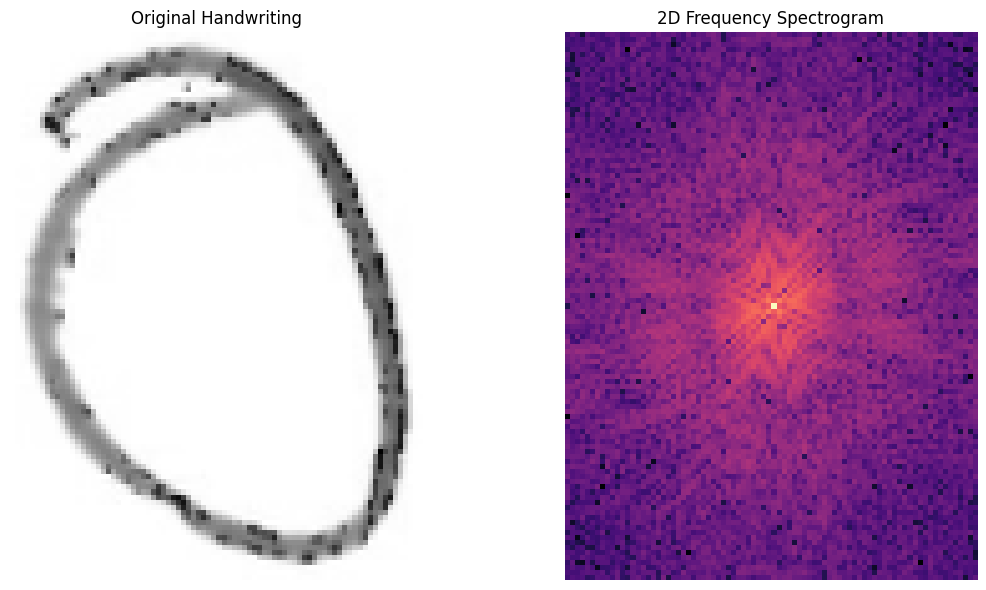

In [4]:
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

def visualize_spectrogram(image_path):
    # 1. Load the image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Could not load image.")
        return

    # 2. Compute the 2D Fast Fourier Transform (FFT)
    # This converts the spatial image into spatial frequencies
    f = np.fft.fft2(img)
    
    # 3. Shift the zero-frequency component (the smooth stuff) to the center of the spectrum
    fshift = np.fft.fftshift(f)
    
    # 4. Calculate the Magnitude Spectrum (The "Spectrogram")
    # We use log scale because frequency energy drops off exponentially
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    # 5. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original Handwriting')
    axes[0].axis('off')
    
    axes[1].imshow(magnitude_spectrum, cmap='magma')
    axes[1].set_title('2D Frequency Spectrogram')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('frequency_spectrogram_demo.png', dpi=300)
    print("SUCCESS! Saved 'frequency_spectrogram_demo.png'.")

# ==========================================
# Grab a valid image from your dataset
# ==========================================
BASE_DIR = "myDataset"
df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path'])
test_image_path = os.path.join(BASE_DIR, str(df['image_path'].iloc[0]))

visualize_spectrogram(test_image_path)

Loading dataset...

SUCCESS! Saved 'spectrogram_comparison.png'.


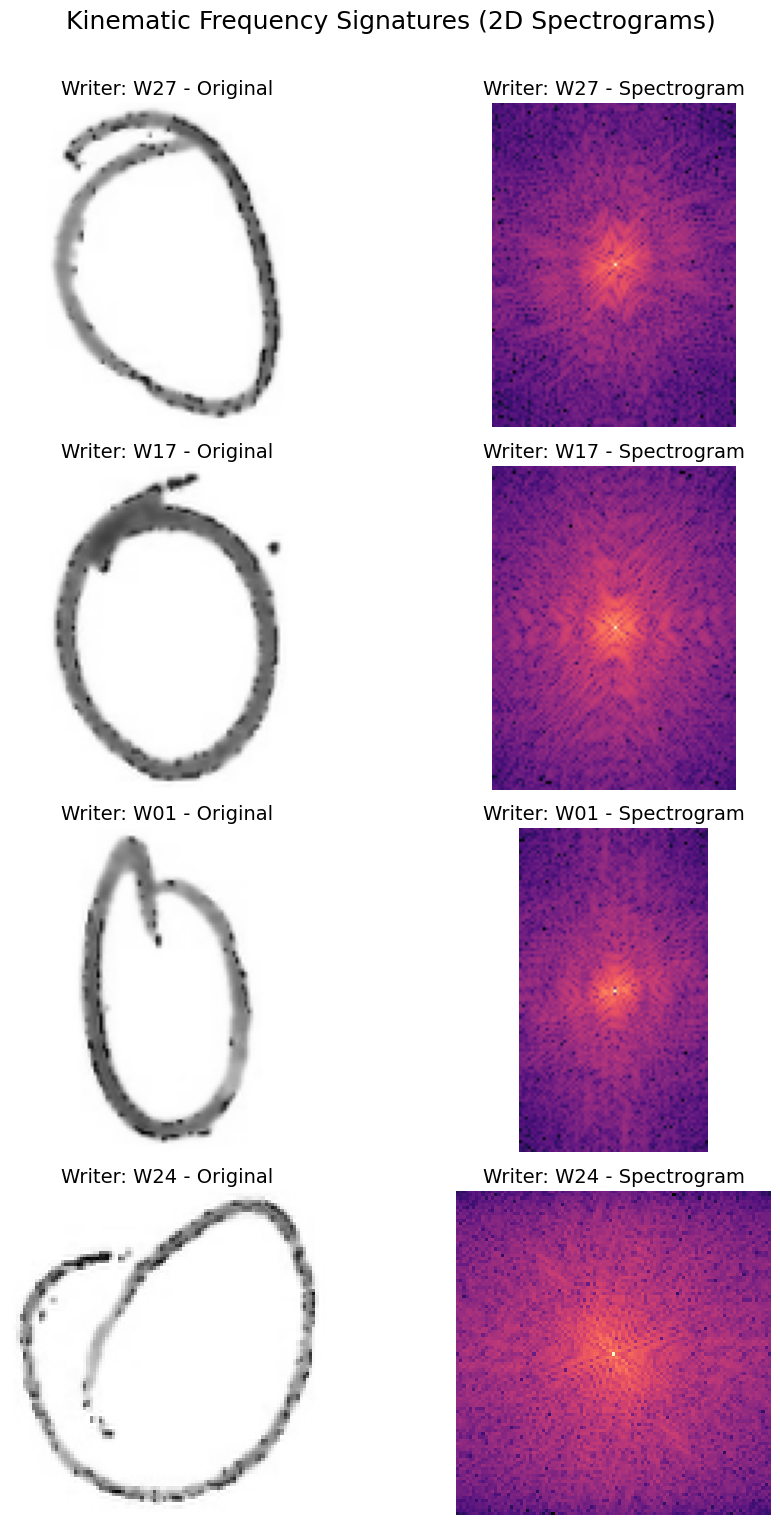

In [5]:
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_DIR = "myDataset"

print("Loading dataset...")
df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path', 'writer_id'])
unique_writers = df['writer_id'].unique()

# Let's pick 4 distinct writers (you can change these IDs if you want specific ones)
# We will just grab the first 4 unique writers found in the dataset
sample_writers = unique_writers[:4] 

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle("Kinematic Frequency Signatures (2D Spectrograms)", fontsize=18)

for i, writer in enumerate(sample_writers):
    # Get the very first image for this specific writer
    img_subpath = df[df['writer_id'] == writer]['image_path'].iloc[0]
    img_path = os.path.join(BASE_DIR, str(img_subpath))
    
    # 1. Load the image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Skipping {writer}: Could not load image at {img_path}")
        continue
        
    # 2. Compute the 2D Fast Fourier Transform (FFT)
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    
    # 3. Calculate the Magnitude Spectrum
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    
    # Plot Original
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f'Writer: {writer} - Original', fontsize=14)
    axes[i, 0].axis('off')
    
    # Plot Spectrogram
    axes[i, 1].imshow(magnitude_spectrum, cmap='magma')
    axes[i, 1].set_title(f'Writer: {writer} - Spectrogram', fontsize=14)
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('spectrogram_comparison.png', dpi=300)
print("\nSUCCESS! Saved 'spectrogram_comparison.png'.")

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import concurrent.futures
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

BASE_DIR = "myDataset"
NUM_CORES = 8

# ==========================================
# 1. THE ULTIMATE BIOMETRIC EXTRACTOR
# ==========================================
def extract_ultimate_fingerprint(row_data):
    idx, img_subpath, writer_id = row_data
    img_path = os.path.join(BASE_DIR, img_subpath)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
        
    inverted = cv2.bitwise_not(img)
    ink_pixels = inverted[inverted > 10]
    if len(ink_pixels) == 0: return None
        
    # --- FEATURE 1: Kinematic Intensity (20 bins) ---
    intensity_hist, _ = np.histogram(ink_pixels, bins=20, range=(10, 255), density=True)
    
    # --- FEATURE 2: Kinematic Thickness (20 bins) ---
    _, binary = cv2.threshold(inverted, 10, 255, cv2.THRESH_BINARY)
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    thickness_values = dist_transform[dist_transform > 0]
    
    if len(thickness_values) > 0:
        width_hist, _ = np.histogram(thickness_values, bins=20, range=(0.1, 15.0), density=True)
    else:
        width_hist = np.zeros(20)

    # --- FEATURE 3: Fourier Spectrogram (20 bins) ---
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    
    # We take the histogram of the spectrogram to measure spatial frequency distribution
    fft_hist, _ = np.histogram(magnitude_spectrum, bins=20, range=(0, 250), density=True)
    
    # Combine into a 60-dimensional fingerprint
    fingerprint = np.concatenate([intensity_hist, width_hist, fft_hist])
    
    return {
        'image_id': img_subpath.split('/')[-1].split('.')[0], 
        'writer_id': str(writer_id),
        'fingerprint': fingerprint
    }

# ==========================================
# 2. MULTI-CORE EXTRACTION PIPELINE
# ==========================================
if __name__ == "__main__":
    print("Loading dataframes...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    
    row_tuples = [(idx, row['image_path'], row['writer_id']) for idx, row in full_df.iterrows()]
    results = []
    
    print(f"\nStarting 8-Core Biometric Extraction on {len(row_tuples)} images...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
        for res in tqdm(executor.map(extract_ultimate_fingerprint, row_tuples), total=len(row_tuples)):
            if res is not None:
                results.append(res)
                
    extracted_df = pd.DataFrame(results)
    
    # Expand the 60-dimensional array into 60 separate columns
    X = np.stack(extracted_df['fingerprint'].values)
    y = extracted_df['writer_id'].values

    # ==========================================
    # 3. RANDOM FOREST TRAINING
    # ==========================================
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
    
    print("\nExtraction Complete! Training Ultimate Biometric Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    print("\nEvaluating on Validation Set...")
    y_pred = rf_model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    print(f"======================================")
    print(f"ULTIMATE BIOMETRIC ACCURACY: {acc * 100:.2f}%")
    print(f"======================================")

    report = classification_report(y_val, y_pred, output_dict=True)
    if '-1' in report:
        print(f"\nPerformance on identifying Strangers ('-1'):")
        print(f"Precision: {report['-1']['precision']:.4f}")
        print(f"Recall:    {report['-1']['recall']:.4f} (Did the Spectrogram catch more than 78%?)")

    joblib.dump(rf_model, "ultimate_biometric_rf.pkl")
    print("\nSaved model to 'ultimate_biometric_rf.pkl'")

Loading dataframes...

Starting 8-Core Biometric Extraction on 40250 images...


100%|███████████████████████████████████| 40250/40250 [00:15<00:00, 2626.98it/s]



Extraction Complete! Training Ultimate Biometric Random Forest...

Evaluating on Validation Set...
ULTIMATE BIOMETRIC ACCURACY: 50.84%

Performance on identifying Strangers ('-1'):
Precision: 0.3255
Recall:    0.8119 (Did the Spectrogram catch more than 78%?)

Saved model to 'ultimate_biometric_rf.pkl'


In [5]:
import os
import cv2
import pandas as pd
import numpy as np
import joblib
import concurrent.futures
from tqdm import tqdm

BASE_DIR = "myDataset"  # Ensure this matches your directory!
TEST_CSV = "myDataset/test.csv"
NUM_CORES = 8

# ==========================================
# 1. ULTIMATE BIOMETRIC EXTRACTOR (60 Features)
# ==========================================
def process_ultimate_test_image(row_data):
    """Worker function to process a single test image."""
    img_id, img_subpath = row_data
    img_path = os.path.join(BASE_DIR, img_subpath)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Fallback for corrupted/missing images
    if img is None: 
        return img_id, np.zeros(60) 
        
    inverted = cv2.bitwise_not(img)
    ink_pixels = inverted[inverted > 10]
    
    if len(ink_pixels) == 0: 
        return img_id, np.zeros(60)
        
    # --- FEATURE 1: Intensity (20 bins) ---
    intensity_hist, _ = np.histogram(ink_pixels, bins=20, range=(10, 255), density=True)
    
    # --- FEATURE 2: Thickness (20 bins) ---
    _, binary = cv2.threshold(inverted, 10, 255, cv2.THRESH_BINARY)
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    thickness_values = dist_transform[dist_transform > 0]
    
    if len(thickness_values) > 0:
        width_hist, _ = np.histogram(thickness_values, bins=20, range=(0.1, 15.0), density=True)
    else:
        width_hist = np.zeros(20)

    # --- FEATURE 3: Frequency Spectrogram (20 bins) ---
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
    fft_hist, _ = np.histogram(magnitude_spectrum, bins=20, range=(0, 250), density=True)
    
    # Combine into the exact 60-dimensional vector the model expects
    fingerprint = np.concatenate([intensity_hist, width_hist, fft_hist])
    
    return img_id, fingerprint

# ==========================================
# 2. INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    print("Loading Ultimate Biometric Random Forest...")
    rf_model = joblib.load("ultimate_biometric_rf.pkl")
    
    print("Loading Kaggle Test Data...")
    test_df = pd.read_csv(TEST_CSV)
    
    row_tuples = [(row['image_id'], row['image_path']) for _, row in test_df.iterrows()]
    extracted_features = []
    
    print(f"Extracting 60-D features using {NUM_CORES} cores...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
        for result in tqdm(executor.map(process_ultimate_test_image, row_tuples), total=len(row_tuples)):
            extracted_features.append(result)
            
    # Unpack results
    image_ids = [res[0] for res in extracted_features]
    X_test = np.array([res[1] for res in extracted_features])
    
    print("\nGenerating Predictions...")
    predictions = rf_model.predict(X_test)
    
    final_predictions = [{'image_id': img_id, 'writer_id': str(pred)} for img_id, pred in zip(image_ids, predictions)]
    
    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_ultimate_rf.csv", index=False)
    
    print("\nSUCCESS! Ultimate RF Submission Generated: submission_ultimate_rf.csv")
    print("\nTop Predicted Classes:")
    print(submission_df['writer_id'].value_counts().head(10))

Loading Ultimate Biometric Random Forest...
Loading Kaggle Test Data...
Extracting 60-D features using 8 cores...


100%|██████████████████████████████████████| 5905/5905 [00:12<00:00, 475.76it/s]



Generating Predictions...

SUCCESS! Ultimate RF Submission Generated: submission_ultimate_rf.csv

Top Predicted Classes:
writer_id
-1     2360
W41     447
W48     346
W49     277
W14     220
W29     217
W37     185
W30     122
W23     112
W13     104
Name: count, dtype: int64


In [7]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==========================================
# 1. THE SPECTROGRAM DATASET
# ==========================================
class SpectrogramDataset(Dataset):
    def __init__(self, dataframe, img_dir, is_train=True):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.is_train = is_train
        
        # Spatial augmentations must happen BEFORE the Fourier Transform
        if self.is_train:
            self.spatial_transform = transforms.Compose([
                transforms.Resize((64, 64)),
                transforms.RandomRotation(15), 
                transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
                transforms.ToTensor() # Converts to [0, 1]
            ])
        else:
            self.spatial_transform = transforms.Compose([
                transforms.Resize((64, 64)),
                transforms.ToTensor()
            ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        
        # 1. Load Spatial Image
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image) # Shape: (1, 64, 64)

        tensor_img = tensor_img - tensor_img.mean()
        # 2. Convert to Frequency Domain (ON THE FLY)
        # We use PyTorch native FFT which is highly optimized
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        
        # 3. Calculate Magnitude Spectrum (Log Scale)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        # 4. Min-Max Normalization (Scale to [0, 1] then [-1, 1] for ConvNeXt)
        min_val = magnitude_spectrum.min()
        max_val = magnitude_spectrum.max()
        normalized_spectrum = (magnitude_spectrum - min_val) / (max_val - min_val + 1e-8)
        final_tensor = (normalized_spectrum - 0.5) / 0.5
        
        label = self.data.loc[idx, 'encoded_label']
        return final_tensor, torch.tensor(label, dtype=torch.long)

# ==========================================
# 2. COLLABORATIVE ARCHITECTURE
# ==========================================
class CollaborativeClassifier(nn.Module):
    def __init__(self, num_classes=46): 
        super().__init__()
        base_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        original_stem = base_model.features[0][0]
        
        # Modify for 1-channel (Grayscale Spectrogram) input
        base_model.features[0][0] = nn.Conv2d(1, original_stem.out_channels, 
                                        kernel_size=original_stem.kernel_size, stride=original_stem.stride)
        
        self.trunk = base_model.features
        self.pool = base_model.avgpool
        self.flatten = nn.Flatten(1)
        in_features = base_model.classifier[2].in_features

        self.independent_experts = nn.Linear(in_features, num_classes)
        self.cross_talk = nn.Sequential(
            nn.Linear(num_classes, num_classes * 2),
            nn.GELU(), 
            nn.Linear(num_classes * 2, num_classes)
        )

    def forward(self, x):
        features = self.trunk(x)
        features = self.pool(features)
        features = self.flatten(features)
        raw_opinions = self.independent_experts(features)
        adjustments = self.cross_talk(raw_opinions)
        return raw_opinions + adjustments

# ==========================================
# 3. TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128 
    NUM_EPOCHS = 40
    LR = 0.0002
    BASE_DIR = "myDataset" # UPDATE THIS TO YOUR ACTUAL PATH
    
    print("Loading Dataframes...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True)
    full_df = full_df.dropna(subset=['image_path', 'writer_id'])
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    unique_writers = sorted(full_df['writer_id'].unique())
    NUM_CLASSES = len(unique_writers)
    
    writer_to_idx = {writer: idx for idx, writer in enumerate(unique_writers)}
    full_df['encoded_label'] = full_df['writer_id'].map(writer_to_idx)
    pd.DataFrame(list(writer_to_idx.items()), columns=['writer_id', 'encoded_label']).to_csv('mapping_spectrogram.csv', index=False)

    train_df, val_df = train_test_split(full_df, test_size=0.15, stratify=full_df['encoded_label'], random_state=42)
    print(f"Spectrogram Train Set: {len(train_df)} | Val Set: {len(val_df)}")

    # Use all 8 of your CPU cores to crunch the FFT math!
    train_loader = DataLoader(SpectrogramDataset(train_df, BASE_DIR, is_train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
    val_loader = DataLoader(SpectrogramDataset(val_df, BASE_DIR, is_train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

    model = CollaborativeClassifier(num_classes=NUM_CLASSES).to(DEVICE)
    
    # Class weights to handle '-1' imbalance
    class_counts = full_df['encoded_label'].value_counts().sort_index().values
    weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
    weights = weights / weights.sum() * NUM_CLASSES 
    criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    best_val_acc = 0.0

    print("\nStarting Spectrogram ConvNeXt Training...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train")
        for images, labels in train_bar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        val_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
        scheduler.step(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_spectrogram_model.pth')
            print("  -> Saved new best model!")

    print(f"\nTraining Complete! Best Spectrogram Val Acc: {best_val_acc:.2f}%")

Loading Dataframes...
Spectrogram Train Set: 34212 | Val Set: 6038

Starting Spectrogram ConvNeXt Training...


Epoch [1/40] Train: 100%|█████████████████████| 268/268 [00:24<00:00, 11.01it/s]


Epoch [1/40] | Train Loss: 3.8099 | Val Acc: 1.99%
  -> Saved new best model!


Epoch [2/40] Train: 100%|█████████████████████| 268/268 [00:24<00:00, 10.83it/s]


Epoch [2/40] | Train Loss: 3.8089 | Val Acc: 1.99%


Epoch [3/40] Train:  18%|███▉                  | 48/268 [00:05<00:26,  8.18it/s]


KeyboardInterrupt: 

In [8]:
import os
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# ==========================================
# 1. THE TRIPLET SPECTROGRAM DATASET
# ==========================================
class TripletSpectrogramDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        
        self.writer_to_indices = self.data.groupby('writer_id').groups
        self.writers = list(self.writer_to_indices.keys())
        
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.RandomRotation(15), 
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def _get_spectrogram(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        # --- THE DC COMPONENT FIX ---
        tensor_img = tensor_img - tensor_img.mean()
        
        # --- ON-THE-FLY FFT ---
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        # Soft normalization for the neural network (-1 to 1 range)
        return magnitude_spectrum / 100.0

    def __getitem__(self, idx):
        # 1. ANCHOR
        anchor_writer = self.data.loc[idx, 'writer_id']
        anchor_spec = self._get_spectrogram(idx)
        
        # 2. POSITIVE
        positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        while positive_idx == idx and len(self.writer_to_indices[anchor_writer]) > 1:
            positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        positive_spec = self._get_spectrogram(positive_idx)
        
        # 3. NEGATIVE
        negative_writer = random.choice(self.writers)
        while negative_writer == anchor_writer:
            negative_writer = random.choice(self.writers)
            
        negative_idx = random.choice(self.writer_to_indices[negative_writer])
        negative_spec = self._get_spectrogram(negative_idx)
        
        return anchor_spec, positive_spec, negative_spec

# ==========================================
# 2. THE SIAMESE FREQ-NET (Shallow Texture Model)
# ==========================================
class SiameseFreqNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseFreqNet, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )
        
        # The Metric Learning Head (Outputs 128-D Coordinates, NOT Classes)
        self.embedder = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5), # Crucial for noisy frequency data
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        embeddings = self.embedder(x)
        # Force all coordinates onto the surface of a hypersphere
        return F.normalize(embeddings, p=2, dim=1) 

# ==========================================
# 3. METRIC LEARNING TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    NUM_EPOCHS = 40
    LR = 0.0005 # Slightly higher LR for shallow networks
    BASE_DIR = "myDataset" # UPDATE THIS TO YOUR PATH
    
    print("Loading data for Siamese FreqNet Learning...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Filter out '-1' for training! We only build islands for known writers.
    train_df = full_df[full_df['writer_id'] != '-1'].reset_index(drop=True)
    print(f"Training on {len(train_df)} known writer images to build frequency islands.")

    # Utilize your 8 CPU Cores to calculate FFTs in parallel
    train_loader = DataLoader(TripletSpectrogramDataset(train_df, BASE_DIR), 
                              batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=8)

    model = SiameseFreqNet(embedding_dim=128).to(DEVICE)
    
    # Triplet Loss: Push matching frequencies together, shove non-matching apart
    criterion = nn.TripletMarginLoss(margin=1.0, p=2) 
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    print("\nStarting Siamese FreqNet Training...")
    best_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        for anchor_spec, positive_spec, negative_spec in progress_bar:
            anchor_spec = anchor_spec.to(DEVICE)
            positive_spec = positive_spec.to(DEVICE)
            negative_spec = negative_spec.to(DEVICE)
            
            optimizer.zero_grad()
            
            # Extract the 128-D frequency coordinates
            anchor_emb = model(anchor_spec)
            positive_emb = model(positive_spec)
            negative_emb = model(negative_spec)
            
            # Calculate Metric Loss
            loss = criterion(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
            
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Average Triplet Loss: {avg_loss:.4f}")
        
        scheduler.step(avg_loss)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'best_siamese_freqnet.pth')
            print("  -> Saved new best Siamese FreqNet model!")

    print("\nTraining Complete! You have successfully built a Frequency-Domain Metric model.")

Loading data for Siamese FreqNet Learning...
Training on 34650 known writer images to build frequency islands.

Starting Siamese FreqNet Training...


Epoch [1/40]: 100%|███████████████| 270/270 [01:11<00:00,  3.78it/s, loss=0.981]


Epoch [1/40] | Average Triplet Loss: 1.0012
  -> Saved new best Siamese FreqNet model!


Epoch [2/40]: 100%|███████████████████| 270/270 [00:21<00:00, 12.47it/s, loss=1]


Epoch [2/40] | Average Triplet Loss: 0.9994
  -> Saved new best Siamese FreqNet model!


...

Epoch [38/40] | Average Triplet Loss: 0.7141


Epoch [39/40]: 100%|██████████████| 270/270 [00:22<00:00, 11.94it/s, loss=0.703]


Epoch [39/40] | Average Triplet Loss: 0.7203


Epoch [40/40]: 100%|██████████████| 270/270 [00:22<00:00, 12.05it/s, loss=0.697]

Epoch [40/40] | Average Triplet Loss: 0.7130
  -> Saved new best Siamese FreqNet model!

Training Complete! You have successfully built a Frequency-Domain Metric model.


In [9]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from scipy.spatial.distance import cdist

# ==========================================
# 1. THE INFERENCE SPECTROGRAM DATASET
# ==========================================
class InferenceSpectrogramDataset(Dataset):
    def __init__(self, dataframe, img_dir, is_test=False):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.is_test = is_test
        
        # NO random rotations/affine during inference! Just resize and tensor.
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        # 1. DC Component Fix (Must match training!)
        tensor_img = tensor_img - tensor_img.mean()
        
        # 2. FFT & Magnitude Spectrum
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        # 3. Normalize
        final_tensor = magnitude_spectrum / 100.0
        
        if self.is_test:
            return final_tensor, self.data.loc[idx, 'image_id']
        else:
            return final_tensor, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. THE SIAMESE FREQ-NET (Must match training exactly)
# ==========================================
class SiameseFreqNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseFreqNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2), 
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2)  
        )
        self.embedder = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5), 
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(inplace=True), nn.Dropout(p=0.3),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.embedder(self.features(x)), p=2, dim=1)

# ==========================================
# 3. KAGGLE INFERENCE LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"  # UPDATE THIS TO YOUR PATH!
    TEST_CSV = "myDataset/test.csv"
    MODEL_PATH = "best_siamese_freqnet.pth"

    print("Loading Trained Siamese FreqNet...")
    model = SiameseFreqNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    # --- STEP 1: MAP THE ISLANDS (CALCULATE CENTROIDS) ---
    print("\nMapping the Known Writers (Calculating Centroids)...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_train = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    full_train['writer_id'] = full_train['writer_id'].astype(str)
    
    known_train = full_train[full_train['writer_id'] != '-1'].reset_index(drop=True)
    
    # Use 8 cores for fast FFT processing
    train_loader = DataLoader(InferenceSpectrogramDataset(known_train, BASE_DIR, is_test=False), 
                              batch_size=128, shuffle=False, num_workers=8)
    
    class_features = {writer: [] for writer in known_train['writer_id'].unique()}
    
    with torch.no_grad():
        for spectrograms, writers in tqdm(train_loader, desc="Extracting Train Embeddings"):
            spectrograms = spectrograms.to(DEVICE)
            embeddings = model(spectrograms).cpu().numpy()
            for emb, writer in zip(embeddings, writers):
                class_features[writer].append(emb)
                
    centroids = {}
    for writer, embeddings in class_features.items():
        mean_emb = np.mean(embeddings, axis=0)
        centroids[writer] = mean_emb / np.linalg.norm(mean_emb) # Re-normalize to hypersphere
        
    centroid_matrix = np.array(list(centroids.values()))
    writer_labels = list(centroids.keys())

    # --- STEP 2: EVALUATE KAGGLE TEST SET ---
    print("\nEvaluating Kaggle Test Set via Triplet Distance...")
    test_df = pd.read_csv(TEST_CSV)
    test_loader = DataLoader(InferenceSpectrogramDataset(test_df, BASE_DIR, is_test=True), 
                             batch_size=128, shuffle=False, num_workers=8)

    final_predictions = []
    
    # --- THE THRESHOLD (The Bouncer's strictness) ---
    STRANGER_DISTANCE_THRESHOLD = 0.90 

    with torch.no_grad():
        for spectrograms, img_ids in tqdm(test_loader, desc="Predicting Test Set"):
            spectrograms = spectrograms.to(DEVICE)
            test_embeddings = model(spectrograms).cpu().numpy()
            
            distances = cdist(test_embeddings, centroid_matrix, metric='euclidean')
            
            for i, img_id in enumerate(img_ids):
                min_dist = np.min(distances[i])
                closest_idx = np.argmin(distances[i])
                
                if min_dist > STRANGER_DISTANCE_THRESHOLD:
                    final_predictions.append({'image_id': img_id, 'writer_id': '-1'})
                else:
                    final_predictions.append({'image_id': img_id, 'writer_id': writer_labels[closest_idx]})

    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_siamese_freqnet.csv", index=False)
    
    print("\nSUCCESS! Siamese FreqNet Submission Generated: submission_siamese_freqnet.csv")
    print("\nTop 10 Predicted Classes:")
    print(submission_df['writer_id'].value_counts().head(10))

Loading Trained Siamese FreqNet...

Mapping the Known Writers (Calculating Centroids)...


Extracting Train Embeddings: 100%|████████████| 271/271 [00:09<00:00, 27.81it/s]



Evaluating Kaggle Test Set via Triplet Distance...


Predicting Test Set: 100%|██████████████████████| 47/47 [00:09<00:00,  4.97it/s]



SUCCESS! Siamese FreqNet Submission Generated: submission_siamese_freqnet.csv

Top 10 Predicted Classes:
writer_id
W48    1295
W28     317
W38     316
W49     244
W39     221
W30     204
W37     194
W07     193
W13     176
W45     175
Name: count, dtype: int64


Loading Trained Siamese FreqNet...
Loading 5 Random Writers for the Autopsy...
Extracting 128-D Brain Scans...
Running t-SNE Dimensionality Reduction (Squashing to 2D)...
Plotting the Islands...

SUCCESS! Open 'tsne_autopsy.png'.


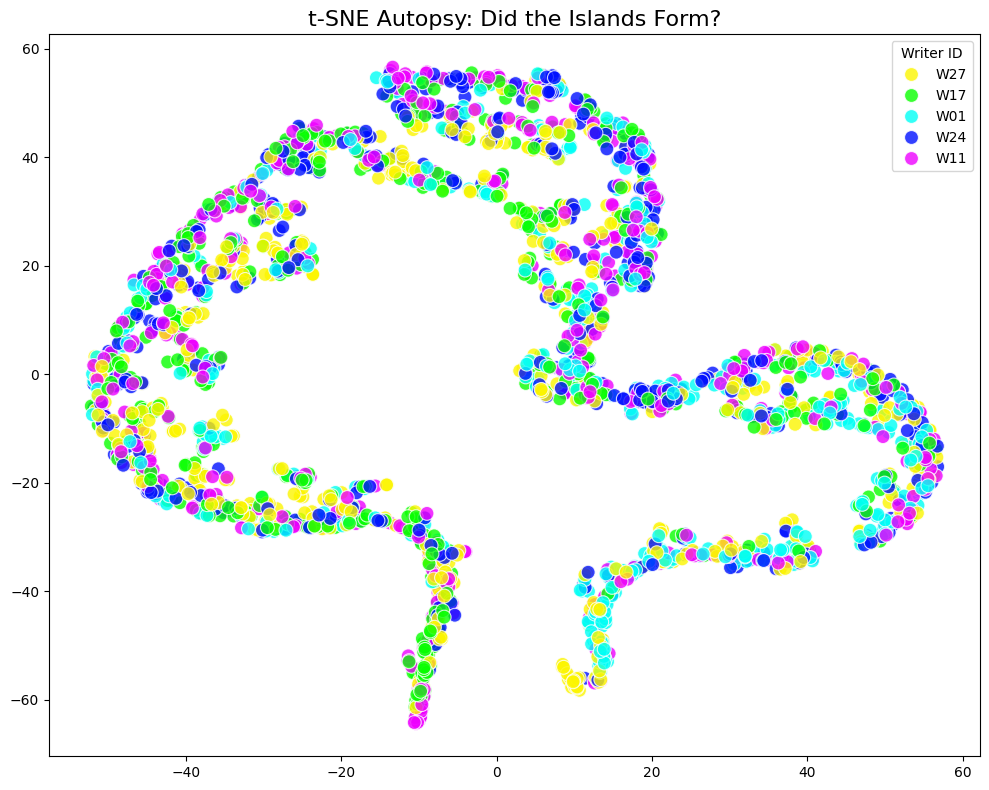

In [10]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==========================================
# 1. THE DATASET (Must match exactly)
# ==========================================
class AutopsyDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        tensor_img = tensor_img - tensor_img.mean() # DC Fix
        
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        return magnitude_spectrum / 100.0, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. THE FREQ-NET (Must match exactly)
# ==========================================
class SiameseFreqNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseFreqNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2), 
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2)  
        )
        self.embedder = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5), 
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(inplace=True), nn.Dropout(p=0.3),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.embedder(self.features(x)), p=2, dim=1)

# ==========================================
# 3. THE AUTOPSY
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"
    MODEL_PATH = "best_siamese_freqnet.pth"

    print("Loading Trained Siamese FreqNet...")
    model = SiameseFreqNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    print("Loading 5 Random Writers for the Autopsy...")
    df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path', 'writer_id'])
    df['writer_id'] = df['writer_id'].astype(str)
    
    # Filter out '-1' and pick 5 distinct writers to keep the graph clean
    known_writers = df[df['writer_id'] != '-1']
    sample_writers = known_writers['writer_id'].unique()[:5]
    autopsy_df = known_writers[known_writers['writer_id'].isin(sample_writers)]

    loader = DataLoader(AutopsyDataset(autopsy_df, BASE_DIR), batch_size=64, shuffle=False)

    all_embeddings = []
    all_labels = []

    print("Extracting 128-D Brain Scans...")
    with torch.no_grad():
        for spectrograms, writers in loader:
            spectrograms = spectrograms.to(DEVICE)
            embeddings = model(spectrograms).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.extend(writers)

    all_embeddings = np.vstack(all_embeddings)

    print("Running t-SNE Dimensionality Reduction (Squashing to 2D)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings)

    print("Plotting the Islands...")
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1],
        hue=all_labels,
        palette=sns.color_palette("hsv", 5),
        s=100, alpha=0.8
    )
    plt.title("t-SNE Autopsy: Did the Islands Form?", fontsize=16)
    plt.legend(title="Writer ID")
    plt.tight_layout()
    plt.savefig("tsne_autopsy.png", dpi=300)
    
    print("\nSUCCESS! Open 'tsne_autopsy.png'.")

In [11]:
import os
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# ==========================================
# 1. THE TRIPLET SPECTROGRAM DATASET
# ==========================================
class TripletSpectrogramDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.writer_to_indices = self.data.groupby('writer_id').groups
        self.writers = list(self.writer_to_indices.keys())
        
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def _get_flat_spectrogram(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        tensor_img = tensor_img - tensor_img.mean()
        
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        normalized_spectrum = magnitude_spectrum / 100.0
        
        # FLATTEN the 64x64 2D grid into a 1D array of 4,096 specific frequencies
        return torch.flatten(normalized_spectrum)

    def __getitem__(self, idx):
        anchor_writer = self.data.loc[idx, 'writer_id']
        anchor_spec = self._get_flat_spectrogram(idx)
        
        positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        while positive_idx == idx and len(self.writer_to_indices[anchor_writer]) > 1:
            positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        positive_spec = self._get_flat_spectrogram(positive_idx)
        
        negative_writer = random.choice(self.writers)
        while negative_writer == anchor_writer:
            negative_writer = random.choice(self.writers)
            
        negative_idx = random.choice(self.writer_to_indices[negative_writer])
        negative_spec = self._get_flat_spectrogram(negative_idx)
        
        return anchor_spec, positive_spec, negative_spec

# ==========================================
# 2. THE SIAMESE DENSE NETWORK (MLP)
# ==========================================
class SiameseDenseNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseDenseNet, self).__init__()
        
        # Input is 64x64 = 4096 specific frequency bins.
        # No convolutions! Just raw pattern matching.
        self.embedder = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        embeddings = self.embedder(x)
        return F.normalize(embeddings, p=2, dim=1) 

# ==========================================
# 3. METRIC LEARNING TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    NUM_EPOCHS = 40
    LR = 0.0003 
    BASE_DIR = "myDataset"
    
    print("Loading data for Siamese Dense Learning...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    train_df = full_df[full_df['writer_id'] != '-1'].reset_index(drop=True)

    train_loader = DataLoader(TripletSpectrogramDataset(train_df, BASE_DIR), 
                              batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=8)

    model = SiameseDenseNet(embedding_dim=128).to(DEVICE)
    
    criterion = nn.TripletMarginLoss(margin=1.0, p=2) 
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

    print("\nStarting Siamese DenseNet Training...")
    best_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        for anchor_spec, positive_spec, negative_spec in progress_bar:
            anchor_spec = anchor_spec.to(DEVICE)
            positive_spec = positive_spec.to(DEVICE)
            negative_spec = negative_spec.to(DEVICE)
            
            optimizer.zero_grad()
            
            anchor_emb = model(anchor_spec)
            positive_emb = model(positive_spec)
            negative_emb = model(negative_spec)
            
            loss = criterion(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
            
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Average Triplet Loss: {avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'best_siamese_dense.pth')
            print("  -> Saved new best Siamese Dense model!")

Loading data for Siamese Dense Learning...

Starting Siamese DenseNet Training...


Epoch [1/40]: 100%|███████████████| 270/270 [00:41<00:00,  6.53it/s, loss=0.669]


Epoch [1/40] | Average Triplet Loss: 0.7511
  -> Saved new best Siamese Dense model!


Epoch [2/40]: 100%|███████████████| 270/270 [00:18<00:00, 14.91it/s, loss=0.619]


Epoch [2/40] | Average Triplet Loss: 0.6583
  -> Saved new best Siamese Dense model!


...

Epoch [38/40] | Average Triplet Loss: 0.3010
  -> Saved new best Siamese Dense model!


Epoch [39/40]: 100%|██████████████| 270/270 [00:18<00:00, 14.85it/s, loss=0.335]


Epoch [39/40] | Average Triplet Loss: 0.2988
  -> Saved new best Siamese Dense model!


Epoch [40/40]: 100%|██████████████| 270/270 [00:18<00:00, 14.81it/s, loss=0.254]


Epoch [40/40] | Average Triplet Loss: 0.2896
  -> Saved new best Siamese Dense model!


Loading Trained Siamese DenseNet...
Loading 5 Random Writers for the Autopsy...
Extracting 128-D Brain Scans...
Running t-SNE Dimensionality Reduction...
Plotting the Islands...

SUCCESS! Open 'tsne_dense_autopsy.png'.


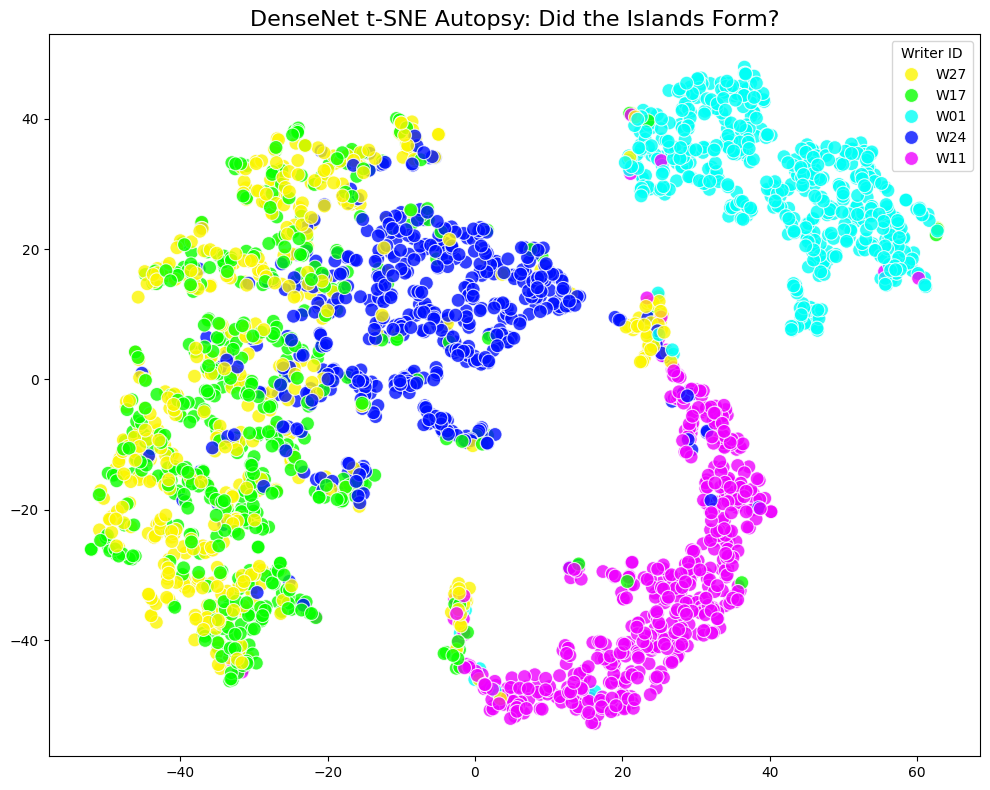

In [14]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==========================================
# 1. THE DATASET (Must flatten the spectrogram)
# ==========================================
class DenseAutopsyDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        # DC Fix
        tensor_img = tensor_img - tensor_img.mean() 
        
        # FFT
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        normalized_spectrum = magnitude_spectrum / 100.0
        
        # Flatten for Dense Network
        flat_spectrum = torch.flatten(normalized_spectrum)
        
        return flat_spectrum, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. THE DENSE NET (Corrected to match training perfectly)
# ==========================================
class SiameseDenseNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseDenseNet, self).__init__()
        self.embedder = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),     # <--- Added back the missing Dropout!
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),     # <--- Added back the missing Dropout!
            
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.embedder(x), p=2, dim=1)
# ==========================================
# 3. THE AUTOPSY
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"  # UPDATE THIS!
    MODEL_PATH = "best_siamese_dense.pth"

    print("Loading Trained Siamese DenseNet...")
    model = SiameseDenseNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    print("Loading 5 Random Writers for the Autopsy...")
    df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path', 'writer_id'])
    df['writer_id'] = df['writer_id'].astype(str)
    
    # Filter out '-1' and pick 5 distinct writers
    known_writers = df[df['writer_id'] != '-1']
    sample_writers = known_writers['writer_id'].unique()[:5]
    autopsy_df = known_writers[known_writers['writer_id'].isin(sample_writers)]

    loader = DataLoader(DenseAutopsyDataset(autopsy_df, BASE_DIR), batch_size=64, shuffle=False)

    all_embeddings = []
    all_labels = []

    print("Extracting 128-D Brain Scans...")
    with torch.no_grad():
        for spectrograms, writers in loader:
            spectrograms = spectrograms.to(DEVICE)
            embeddings = model(spectrograms).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.extend(writers)

    all_embeddings = np.vstack(all_embeddings)

    print("Running t-SNE Dimensionality Reduction...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings)

    print("Plotting the Islands...")
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1],
        hue=all_labels,
        palette=sns.color_palette("hsv", 5),
        s=100, alpha=0.8
    )
    plt.title("DenseNet t-SNE Autopsy: Did the Islands Form?", fontsize=16)
    plt.legend(title="Writer ID")
    plt.tight_layout()
    plt.savefig("tsne_dense_autopsy.png", dpi=300)
    
    print("\nSUCCESS! Open 'tsne_dense_autopsy.png'.")

In [2]:
import os
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# ==========================================
# 1. THE TRIPLET SPECTROGRAM DATASET (With Radial Crop)
# ==========================================
class TripletSpectrogramDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        
        # Group indices by writer to easily pick Positives and Negatives
        self.writer_to_indices = self.data.groupby('writer_id').groups
        self.writers = list(self.writer_to_indices.keys())
        
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def _get_flat_spectrogram(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        # --- FIX 1: Remove DC Component ---
        tensor_img = tensor_img - tensor_img.mean()
        
        # --- FFT MATH ---
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        normalized_spectrum = magnitude_spectrum / 100.0
        
        # --- FIX 2: The Radial Crop (Low-Pass Filter) ---
        # Crop the 64x64 tensor down to the center 32x32 pixels
        # This deletes the high-frequency scanner noise on the edges
        cropped_spectrum = normalized_spectrum[:, 16:48, 16:48] 
        
        # Flatten the 32x32 grid into a 1D array of 1,024 core frequencies
        return torch.flatten(cropped_spectrum)

    def __getitem__(self, idx):
        # 1. ANCHOR
        anchor_writer = self.data.loc[idx, 'writer_id']
        anchor_spec = self._get_flat_spectrogram(idx)
        
        # 2. POSITIVE (Same Writer)
        positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        while positive_idx == idx and len(self.writer_to_indices[anchor_writer]) > 1:
            positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        positive_spec = self._get_flat_spectrogram(positive_idx)
        
        # 3. NEGATIVE (Different Writer)
        negative_writer = random.choice(self.writers)
        while negative_writer == anchor_writer:
            negative_writer = random.choice(self.writers)
            
        negative_idx = random.choice(self.writer_to_indices[negative_writer])
        negative_spec = self._get_flat_spectrogram(negative_idx)
        
        return anchor_spec, positive_spec, negative_spec

# ==========================================
# 2. THE SIAMESE DENSE NETWORK (MLP)
# ==========================================
class SiameseDenseNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseDenseNet, self).__init__()
        
        self.embedder = nn.Sequential(
            # Input is exactly 1024 (the cropped core frequencies)
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), # Crucial to prevent memorizing random noise
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        # Force all coordinates onto the surface of a hypersphere
        return F.normalize(self.embedder(x), p=2, dim=1) 

# ==========================================
# 3. METRIC LEARNING TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    NUM_EPOCHS = 40
    LR = 0.0003 
    BASE_DIR = "myDataset" # <--- Ensure this matches your path
    
    print("Loading data for Cropped Siamese Dense Learning...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    full_df['writer_id'] = full_df['writer_id'].astype(str)
    
    # Filter out '-1' for training! We only build islands for known writers.
    train_df = full_df[full_df['writer_id'] != '-1'].reset_index(drop=True)
    print(f"Training on {len(train_df)} known writer images.")

    # Utilize your 8 CPU Cores to calculate FFTs in parallel
    train_loader = DataLoader(TripletSpectrogramDataset(train_df, BASE_DIR), 
                              batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=8)

    model = SiameseDenseNet(embedding_dim=128).to(DEVICE)
    
    # Triplet Loss: Push matching frequencies together, shove non-matching apart
    criterion = nn.TripletMarginLoss(margin=1.0, p=2) 
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    print("\nStarting Siamese DenseNet (Cropped) Training...")
    best_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        for anchor_spec, positive_spec, negative_spec in progress_bar:
            anchor_spec = anchor_spec.to(DEVICE)
            positive_spec = positive_spec.to(DEVICE)
            negative_spec = negative_spec.to(DEVICE)
            
            optimizer.zero_grad()
            
            # Extract the 128-D frequency coordinates
            anchor_emb = model(anchor_spec)
            positive_emb = model(positive_spec)
            negative_emb = model(negative_spec)
            
            # Calculate Metric Loss
            loss = criterion(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
            
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Average Triplet Loss: {avg_loss:.4f}")
        
        scheduler.step(avg_loss)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            # Note the new save name so we don't overwrite the old one
            torch.save(model.state_dict(), 'best_siamese_dense_cropped.pth')
            print("  -> Saved new best Cropped Siamese Dense model!")

    print("\nTraining Complete! Let's see if we finally broke the hairball.")

Loading data for Cropped Siamese Dense Learning...
Training on 34650 known writer images.

Starting Siamese DenseNet (Cropped) Training...


Epoch [1/40]: 100%|███████████████| 270/270 [00:45<00:00,  5.94it/s, loss=0.684]


Epoch [1/40] | Average Triplet Loss: 0.7647
  -> Saved new best Cropped Siamese Dense model!


Epoch [2/40]: 100%|████████████████| 270/270 [00:16<00:00, 16.36it/s, loss=0.56]


Epoch [2/40] | Average Triplet Loss: 0.6603
  -> Saved new best Cropped Siamese Dense model!


...

Epoch [38/40] | Average Triplet Loss: 0.4634
  -> Saved new best Cropped Siamese Dense model!


Epoch [39/40]: 100%|██████████████| 270/270 [00:16<00:00, 16.59it/s, loss=0.514]


Epoch [39/40] | Average Triplet Loss: 0.4587
  -> Saved new best Cropped Siamese Dense model!


Epoch [40/40]: 100%|██████████████| 270/270 [00:16<00:00, 16.39it/s, loss=0.462]

Epoch [40/40] | Average Triplet Loss: 0.4556
  -> Saved new best Cropped Siamese Dense model!

Training Complete! Let's see if we finally broke the hairball.


Loading Trained Cropped DenseNet...
Loading 5 Random Writers for the Autopsy...
Extracting 128-D Brain Scans...
Running t-SNE Dimensionality Reduction...
Plotting the Islands...

SUCCESS! Open 'tsne_dense_cropped_autopsy.png'.


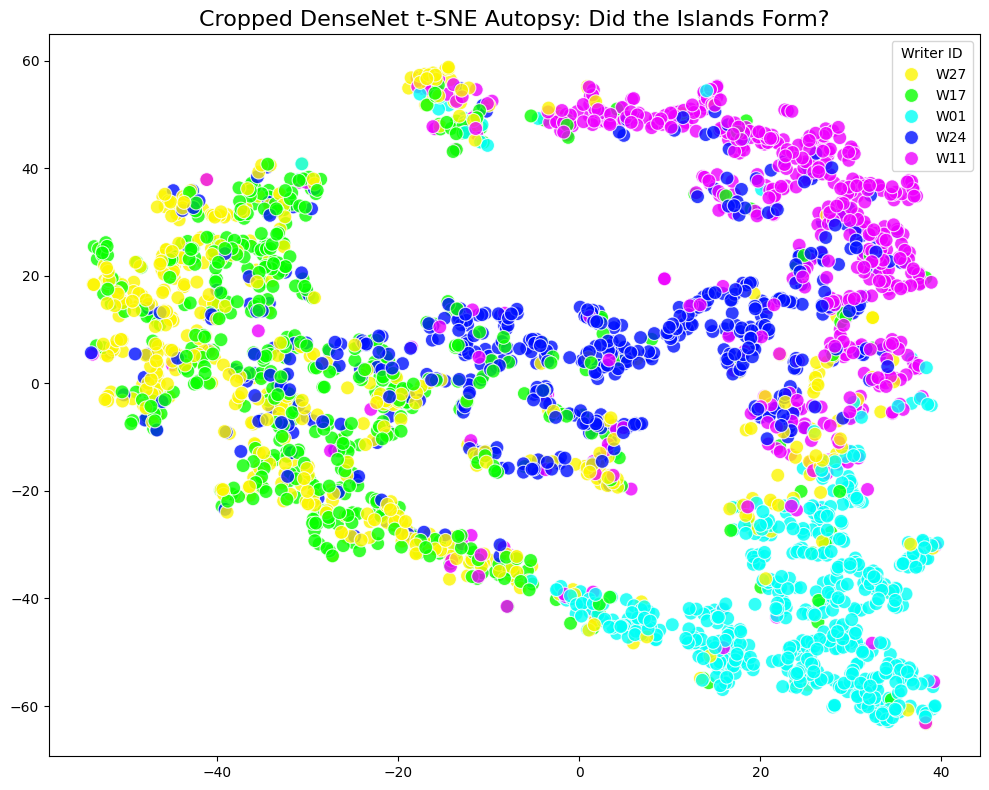

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==========================================
# 1. THE DATASET (Must include Radial Crop)
# ==========================================
class CroppedAutopsyDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        image = Image.open(img_path).convert('L')
        tensor_img = self.spatial_transform(image)
        
        # DC Fix
        tensor_img = tensor_img - tensor_img.mean() 
        
        # FFT
        fft2 = torch.fft.fft2(tensor_img)
        fft_shift = torch.fft.fftshift(fft2)
        magnitude_spectrum = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        
        normalized_spectrum = magnitude_spectrum / 100.0
        
        # --- THE RADIAL CROP ---
        cropped_spectrum = normalized_spectrum[:, 16:48, 16:48] 
        flat_spectrum = torch.flatten(cropped_spectrum)
        
        return flat_spectrum, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. THE DENSE NET (Input must be 1024)
# ==========================================
class SiameseDenseNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseDenseNet, self).__init__()
        self.embedder = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        return F.normalize(self.embedder(x), p=2, dim=1)

# ==========================================
# 3. THE AUTOPSY
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"  # UPDATE THIS!
    MODEL_PATH = "best_siamese_dense_cropped.pth"

    print("Loading Trained Cropped DenseNet...")
    model = SiameseDenseNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    print("Loading 5 Random Writers for the Autopsy...")
    df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path', 'writer_id'])
    df['writer_id'] = df['writer_id'].astype(str)
    
    # Filter out '-1' and pick 5 distinct writers
    known_writers = df[df['writer_id'] != '-1']
    sample_writers = known_writers['writer_id'].unique()[:5]
    autopsy_df = known_writers[known_writers['writer_id'].isin(sample_writers)]

    loader = DataLoader(CroppedAutopsyDataset(autopsy_df, BASE_DIR), batch_size=64, shuffle=False)

    all_embeddings = []
    all_labels = []

    print("Extracting 128-D Brain Scans...")
    with torch.no_grad():
        for spectrograms, writers in loader:
            spectrograms = spectrograms.to(DEVICE)
            embeddings = model(spectrograms).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.extend(writers)

    all_embeddings = np.vstack(all_embeddings)

    print("Running t-SNE Dimensionality Reduction...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings)

    print("Plotting the Islands...")
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1],
        hue=all_labels,
        palette=sns.color_palette("hsv", 5),
        s=100, alpha=0.8
    )
    plt.title("Cropped DenseNet t-SNE Autopsy: Did the Islands Form?", fontsize=16)
    plt.legend(title="Writer ID")
    plt.tight_layout()
    plt.savefig("tsne_dense_cropped_autopsy.png", dpi=300)
    
    print("\nSUCCESS! Open 'tsne_dense_cropped_autopsy.png'.")

In [4]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import silhouette_samples
from tqdm import tqdm

# ==========================================
# 1. THE DATASET & MODEL (Matches your last run)
# ==========================================
class CroppedAutopsyDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)), transforms.ToTensor()
        ])
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        tensor_img = self.spatial_transform(Image.open(img_path).convert('L'))
        tensor_img = tensor_img - tensor_img.mean() 
        fft_shift = torch.fft.fftshift(torch.fft.fft2(tensor_img))
        mag_spec = 20 * torch.log(torch.abs(fft_shift) + 1e-8) / 100.0
        cropped = mag_spec[:, 16:48, 16:48] 
        return torch.flatten(cropped), self.data.loc[idx, 'writer_id']

class SiameseDenseNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseDenseNet, self).__init__()
        self.embedder = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(p=0.4),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(p=0.3),
            nn.Linear(256, embedding_dim)
        )
    def forward(self, x): return F.normalize(self.embedder(x), p=2, dim=1)

# ==========================================
# 2. THE MATHEMATICAL AUTOPSY
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"  # UPDATE THIS!
    MODEL_PATH = "best_siamese_dense_cropped.pth"

    print("Loading Trained Cropped DenseNet...")
    model = SiameseDenseNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    print("Loading all known writers...")
    df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path', 'writer_id'])
    df['writer_id'] = df['writer_id'].astype(str)
    known_writers_df = df[df['writer_id'] != '-1'].reset_index(drop=True)

    # Use a large batch size and all your cores to extract fast
    loader = DataLoader(CroppedAutopsyDataset(known_writers_df, BASE_DIR), batch_size=256, shuffle=False, num_workers=8)

    all_embeddings = []
    all_labels = []

    print("Extracting 128-D Coordinates...")
    with torch.no_grad():
        for spectrograms, writers in tqdm(loader):
            embeddings = model(spectrograms.to(DEVICE)).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.extend(writers)

    all_embeddings = np.vstack(all_embeddings)
    all_labels = np.array(all_labels)

    print("\nCalculating Silhouette Scores (Island Integrity)...")
    # This calculates how well separated EVERY single image is
    sample_scores = silhouette_samples(all_embeddings, all_labels, metric='euclidean')

    # Group the scores by writer to see who formed islands and who formed hairballs
    results = []
    for writer in np.unique(all_labels):
        writer_scores = sample_scores[all_labels == writer]
        avg_score = np.mean(writer_scores)
        results.append({'writer_id': writer, 'silhouette_score': avg_score})

    results_df = pd.DataFrame(results).sort_values(by='silhouette_score', ascending=False)
    results_df.to_csv("writer_viability_report.csv", index=False)

    print("\n==========================================")
    print("TOP 5 STRONGEST WRITERS (The Perfect Islands):")
    print(results_df.head(5))
    print("\nBOTTOM 5 WEAKEST WRITERS (The Hairballs):")
    print(results_df.tail(5))
    print("==========================================")
    print("\nFull report saved to 'writer_viability_report.csv'")

Loading Trained Cropped DenseNet...
Loading all known writers...
Extracting 128-D Coordinates...


100%|███████████████████████████████████████████| 94/94 [00:23<00:00,  4.03it/s]



Calculating Silhouette Scores (Island Integrity)...

TOP 5 STRONGEST WRITERS (The Perfect Islands):
   writer_id  silhouette_score
6        W08          0.177246
37       W44          0.175191
24       W30          0.173586
25       W32          0.081602
41       W49          0.061955

BOTTOM 5 WEAKEST WRITERS (The Hairballs):
   writer_id  silhouette_score
39       W46         -0.449829
36       W43         -0.454556
34       W41         -0.464955
9        W11         -0.486721
10       W12         -0.604526

Full report saved to 'writer_viability_report.csv'


In [5]:
import os
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# ==========================================
# 1. THE PYRAMIDAL DATASET (3 Lenses)
# ==========================================
class PyramidalSpectrogramDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.writer_to_indices = self.data.groupby('writer_id').groups
        self.writers = list(self.writer_to_indices.keys())
        
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def _get_pyramid(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        tensor_img = self.spatial_transform(Image.open(img_path).convert('L'))
        
        tensor_img = tensor_img - tensor_img.mean() # DC Fix
        
        fft_shift = torch.fft.fftshift(torch.fft.fft2(tensor_img))
        mag_spec = 20 * torch.log(torch.abs(fft_shift) + 1e-8)
        norm_spec = mag_spec / 100.0
        
        # LENS 1: Full 64x64 (High Frequency) -> 4096 dims
        full_64 = torch.flatten(norm_spec)
        
        # LENS 2: Mid 32x32 (Mid Frequency Slant) -> 1024 dims
        mid_32 = torch.flatten(norm_spec[:, 16:48, 16:48])
        
        # LENS 3: Core 16x16 (Low Frequency Smoothness) -> 256 dims
        core_16 = torch.flatten(norm_spec[:, 24:40, 24:40])
        
        return full_64, mid_32, core_16

    def __getitem__(self, idx):
        anchor_writer = self.data.loc[idx, 'writer_id']
        anchor_64, anchor_32, anchor_16 = self._get_pyramid(idx)
        
        positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        while positive_idx == idx and len(self.writer_to_indices[anchor_writer]) > 1:
            positive_idx = random.choice(self.writer_to_indices[anchor_writer])
        pos_64, pos_32, pos_16 = self._get_pyramid(positive_idx)
        
        negative_writer = random.choice(self.writers)
        while negative_writer == anchor_writer:
            negative_writer = random.choice(self.writers)
            
        negative_idx = random.choice(self.writer_to_indices[negative_writer])
        neg_64, neg_32, neg_16 = self._get_pyramid(negative_idx)
        
        return (anchor_64, anchor_32, anchor_16), (pos_64, pos_32, pos_16), (neg_64, neg_32, neg_16)

# ==========================================
# 2. THE PYRAMIDAL ATTENTION NETWORK
# ==========================================
class SiamesePyramidalNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiamesePyramidalNet, self).__init__()
        
        # Project all 3 lenses into a common 256-dimensional space
        self.proj_64 = nn.Sequential(nn.Linear(4096, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 256))
        self.proj_32 = nn.Sequential(nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 256))
        self.proj_16 = nn.Sequential(nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 256))
        
        # The Attention Mechanism (Decides which lens matters most)
        self.attention = nn.Sequential(
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        self.final_embedder = nn.Sequential(
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x_64, x_32, x_16):
        # 1. Extract Features from all 3 lenses
        feat_64 = self.proj_64(x_64).unsqueeze(1) # Shape: [Batch, 1, 256]
        feat_32 = self.proj_32(x_32).unsqueeze(1) # Shape: [Batch, 1, 256]
        feat_16 = self.proj_16(x_16).unsqueeze(1) # Shape: [Batch, 1, 256]
        
        # 2. Stack them together: [Batch, 3, 256]
        stacked_features = torch.cat([feat_64, feat_32, feat_16], dim=1)
        
        # 3. Calculate Attention Weights for the 3 lenses
        attn_scores = self.attention(stacked_features) # [Batch, 3, 1]
        attn_weights = F.softmax(attn_scores, dim=1)   # [Batch, 3, 1]
        
        # 4. Multiply features by their attention weight and sum them up
        weighted_features = torch.sum(stacked_features * attn_weights, dim=1) # [Batch, 256]
        
        # 5. Final Metric Embedding
        embeddings = self.final_embedder(weighted_features)
        return F.normalize(embeddings, p=2, dim=1)

# ==========================================
# 3. TRAINING LOOP
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    NUM_EPOCHS = 40
    LR = 0.0003 
    BASE_DIR = "myDataset" # UPDATE THIS
    
    print("Loading data for Pyramidal Attention Learning...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_df = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    train_df = full_df[full_df['writer_id'].astype(str) != '-1'].reset_index(drop=True)

    train_loader = DataLoader(PyramidalSpectrogramDataset(train_df, BASE_DIR), 
                              batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=8)

    model = SiamesePyramidalNet(embedding_dim=128).to(DEVICE)
    criterion = nn.TripletMarginLoss(margin=1.0, p=2) 
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

    print("\nStarting Siamese Pyramidal Network Training...")
    best_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        for anchor_tuple, pos_tuple, neg_tuple in progress_bar:
            
            # Unpack the 3 lenses for each
            a_64, a_32, a_16 = [x.to(DEVICE) for x in anchor_tuple]
            p_64, p_32, p_16 = [x.to(DEVICE) for x in pos_tuple]
            n_64, n_32, n_16 = [x.to(DEVICE) for x in neg_tuple]
            
            optimizer.zero_grad()
            
            anchor_emb = model(a_64, a_32, a_16)
            positive_emb = model(p_64, p_32, p_16)
            negative_emb = model(n_64, n_32, n_16)
            
            loss = criterion(anchor_emb, positive_emb, negative_emb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
            
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Pyramidal Triplet Loss: {avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'best_siamese_pyramidal.pth')
            print("  -> Saved new best Pyramidal Attention model!")

Loading data for Pyramidal Attention Learning...

Starting Siamese Pyramidal Network Training...


Epoch [1/40]: 100%|████████████████| 270/270 [00:46<00:00,  5.85it/s, loss=0.63]


Epoch [1/40] | Pyramidal Triplet Loss: 0.6763
  -> Saved new best Pyramidal Attention model!


Epoch [2/40]: 100%|███████████████| 270/270 [00:16<00:00, 15.90it/s, loss=0.543]


Epoch [2/40] | Pyramidal Triplet Loss: 0.6064
  -> Saved new best Pyramidal Attention model!


...

Epoch [38/40] | Pyramidal Triplet Loss: 0.2543
  -> Saved new best Pyramidal Attention model!


Epoch [39/40]: 100%|██████████████| 270/270 [00:16<00:00, 15.95it/s, loss=0.216]


Epoch [39/40] | Pyramidal Triplet Loss: 0.2492
  -> Saved new best Pyramidal Attention model!


Epoch [40/40]: 100%|██████████████| 270/270 [00:16<00:00, 15.92it/s, loss=0.293]


Epoch [40/40] | Pyramidal Triplet Loss: 0.2485
  -> Saved new best Pyramidal Attention model!


Loading Trained Pyramidal Network...
Loading Target Writers (The Best and The Worst)...
Extracting Pyramidal Embeddings...
Running t-SNE...
Plotting the Rescued Islands...

SUCCESS! Open 'tsne_pyramidal_autopsy.png'.


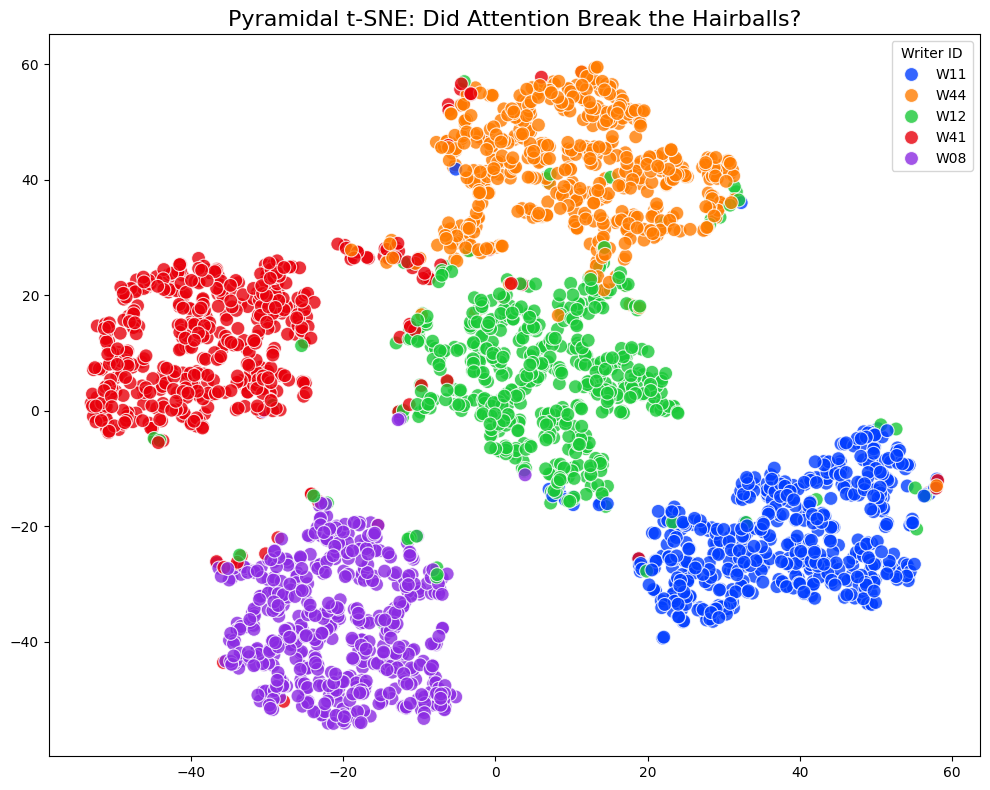

In [6]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==========================================
# 1. THE DATASET (Must return all 3 lenses)
# ==========================================
class PyramidalAutopsyDataset(Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)), transforms.ToTensor()
        ])

    def __len__(self): return len(self.data)

    def _get_pyramid(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        tensor_img = self.spatial_transform(Image.open(img_path).convert('L'))
        
        tensor_img = tensor_img - tensor_img.mean()
        
        fft_shift = torch.fft.fftshift(torch.fft.fft2(tensor_img))
        norm_spec = 20 * torch.log(torch.abs(fft_shift) + 1e-8) / 100.0
        
        full_64 = torch.flatten(norm_spec)
        mid_32 = torch.flatten(norm_spec[:, 16:48, 16:48])
        core_16 = torch.flatten(norm_spec[:, 24:40, 24:40])
        
        return full_64, mid_32, core_16

    def __getitem__(self, idx):
        f64, m32, c16 = self._get_pyramid(idx)
        return f64, m32, c16, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. THE PYRAMIDAL NETWORK (Exact Match)
# ==========================================
class SiamesePyramidalNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiamesePyramidalNet, self).__init__()
        self.proj_64 = nn.Sequential(nn.Linear(4096, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 256))
        self.proj_32 = nn.Sequential(nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 256))
        self.proj_16 = nn.Sequential(nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 256))
        
        self.attention = nn.Sequential(nn.Linear(256, 64), nn.Tanh(), nn.Linear(64, 1))
        self.final_embedder = nn.Sequential(nn.Linear(256, embedding_dim))

    def forward(self, x_64, x_32, x_16):
        feat_64 = self.proj_64(x_64).unsqueeze(1)
        feat_32 = self.proj_32(x_32).unsqueeze(1)
        feat_16 = self.proj_16(x_16).unsqueeze(1)
        
        stacked_features = torch.cat([feat_64, feat_32, feat_16], dim=1)
        attn_scores = self.attention(stacked_features)
        attn_weights = F.softmax(attn_scores, dim=1)
        
        weighted_features = torch.sum(stacked_features * attn_weights, dim=1)
        embeddings = self.final_embedder(weighted_features)
        return F.normalize(embeddings, p=2, dim=1)

# ==========================================
# 3. THE TARGETED AUTOPSY
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"  # UPDATE THIS
    MODEL_PATH = "best_siamese_pyramidal.pth"

    print("Loading Trained Pyramidal Network...")
    model = SiamesePyramidalNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    print("Loading Target Writers (The Best and The Worst)...")
    df = pd.read_csv('myDataset/train.csv').dropna(subset=['image_path', 'writer_id'])
    df['writer_id'] = df['writer_id'].astype(str)
    
    # We deliberately target the writers from our viability report
    target_writers = ['W08', 'W44', 'W12', 'W11', 'W41']
    autopsy_df = df[df['writer_id'].isin(target_writers)].reset_index(drop=True)

    loader = DataLoader(PyramidalAutopsyDataset(autopsy_df, BASE_DIR), batch_size=64, shuffle=False)

    all_embeddings = []
    all_labels = []

    print("Extracting Pyramidal Embeddings...")
    with torch.no_grad():
        for f64, m32, c16, writers in loader:
            f64, m32, c16 = f64.to(DEVICE), m32.to(DEVICE), c16.to(DEVICE)
            embeddings = model(f64, m32, c16).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.extend(writers)

    all_embeddings = np.vstack(all_embeddings)

    print("Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings)

    print("Plotting the Rescued Islands...")
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1],
        hue=all_labels,
        palette=sns.color_palette("bright", 5),
        s=100, alpha=0.8
    )
    plt.title("Pyramidal t-SNE: Did Attention Break the Hairballs?", fontsize=16)
    plt.legend(title="Writer ID", loc='best')
    plt.tight_layout()
    plt.savefig("tsne_pyramidal_autopsy.png", dpi=300)
    
    print("\nSUCCESS! Open 'tsne_pyramidal_autopsy.png'.")

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from scipy.spatial.distance import cdist

# ==========================================
# 1. THE INFERENCE DATASET
# ==========================================
class PyramidalInferenceDataset(Dataset):
    def __init__(self, dataframe, img_dir, is_test=False):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.is_test = is_test
        self.spatial_transform = transforms.Compose([
            transforms.Resize((64, 64)), transforms.ToTensor()
        ])

    def __len__(self): return len(self.data)

    def _get_pyramid(self, idx):
        img_path = os.path.join(self.img_dir, self.data.loc[idx, 'image_path'])
        tensor_img = self.spatial_transform(Image.open(img_path).convert('L'))
        
        tensor_img = tensor_img - tensor_img.mean() # DC Fix
        
        fft_shift = torch.fft.fftshift(torch.fft.fft2(tensor_img))
        norm_spec = 20 * torch.log(torch.abs(fft_shift) + 1e-8) / 100.0
        
        full_64 = torch.flatten(norm_spec)
        mid_32 = torch.flatten(norm_spec[:, 16:48, 16:48])
        core_16 = torch.flatten(norm_spec[:, 24:40, 24:40])
        
        return full_64, mid_32, core_16

    def __getitem__(self, idx):
        f64, m32, c16 = self._get_pyramid(idx)
        if self.is_test:
            return f64, m32, c16, self.data.loc[idx, 'image_id']
        else:
            return f64, m32, c16, self.data.loc[idx, 'writer_id']

# ==========================================
# 2. THE PYRAMIDAL NETWORK (Must Match Training)
# ==========================================
class SiamesePyramidalNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiamesePyramidalNet, self).__init__()
        self.proj_64 = nn.Sequential(nn.Linear(4096, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 256))
        self.proj_32 = nn.Sequential(nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 256))
        self.proj_16 = nn.Sequential(nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 256))
        
        self.attention = nn.Sequential(nn.Linear(256, 64), nn.Tanh(), nn.Linear(64, 1))
        self.final_embedder = nn.Sequential(nn.Linear(256, embedding_dim))

    def forward(self, x_64, x_32, x_16):
        feat_64, feat_32, feat_16 = self.proj_64(x_64).unsqueeze(1), self.proj_32(x_32).unsqueeze(1), self.proj_16(x_16).unsqueeze(1)
        stacked_features = torch.cat([feat_64, feat_32, feat_16], dim=1)
        attn_weights = F.softmax(self.attention(stacked_features), dim=1)
        weighted_features = torch.sum(stacked_features * attn_weights, dim=1)
        return F.normalize(self.final_embedder(weighted_features), p=2, dim=1)

# ==========================================
# 3. KAGGLE INFERENCE PIPELINE
# ==========================================
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BASE_DIR = "myDataset"  # UPDATE THIS!
    TEST_CSV = "myDataset/test.csv"
    MODEL_PATH = "best_siamese_pyramidal.pth"

    print("Loading Trained Pyramidal Network...")
    model = SiamesePyramidalNet(embedding_dim=128).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    # --- STEP 1: CALCULATE THE ISLAND CENTROIDS ---
    print("\nMapping the Known Writers (Calculating Centroids)...")
    df1 = pd.read_csv('myDataset/train.csv')
    df2 = pd.read_csv('myDataset/additional_train.csv')
    full_train = pd.concat([df1, df2], ignore_index=True).dropna(subset=['image_path', 'writer_id'])
    full_train['writer_id'] = full_train['writer_id'].astype(str)
    
    known_train = full_train[full_train['writer_id'] != '-1'].reset_index(drop=True)
    train_loader = DataLoader(PyramidalInferenceDataset(known_train, BASE_DIR, is_test=False), 
                              batch_size=128, shuffle=False, num_workers=8)
    
    class_features = {writer: [] for writer in known_train['writer_id'].unique()}
    
    with torch.no_grad():
        for f64, m32, c16, writers in tqdm(train_loader, desc="Extracting Train Embeddings"):
            embeddings = model(f64.to(DEVICE), m32.to(DEVICE), c16.to(DEVICE)).cpu().numpy()
            for emb, writer in zip(embeddings, writers):
                class_features[writer].append(emb)
                
    centroids = {}
    for writer, embeddings in class_features.items():
        mean_emb = np.mean(embeddings, axis=0)
        centroids[writer] = mean_emb / np.linalg.norm(mean_emb) # Re-normalize to surface
        
    centroid_matrix = np.array(list(centroids.values()))
    writer_labels = list(centroids.keys())

    # --- STEP 2: PREDICT ON KAGGLE TEST SET ---
    print("\nEvaluating Kaggle Test Set...")
    test_df = pd.read_csv(TEST_CSV)
    test_loader = DataLoader(PyramidalInferenceDataset(test_df, BASE_DIR, is_test=True), 
                             batch_size=128, shuffle=False, num_workers=8)

    final_predictions = []
    
    # ------------------------------------------------
    # THE MASTER THRESHOLD
    # > 0.85: The image is too far from any known writer. It is a stranger.
    # < 0.85: The image landed on a known island.
    # ------------------------------------------------
    STRANGER_DISTANCE_THRESHOLD = 0.50

    with torch.no_grad():
        for f64, m32, c16, img_ids in tqdm(test_loader, desc="Predicting Test Set"):
            test_embeddings = model(f64.to(DEVICE), m32.to(DEVICE), c16.to(DEVICE)).cpu().numpy()
            
            distances = cdist(test_embeddings, centroid_matrix, metric='euclidean')
            
            for i, img_id in enumerate(img_ids):
                min_dist = np.min(distances[i])
                closest_idx = np.argmin(distances[i])
                
                if min_dist > STRANGER_DISTANCE_THRESHOLD:
                    final_predictions.append({'image_id': img_id, 'writer_id': '-1'})
                else:
                    final_predictions.append({'image_id': img_id, 'writer_id': writer_labels[closest_idx]})

    submission_df = pd.DataFrame(final_predictions)
    submission_df.to_csv("submission_pyramidal.csv", index=False)
    
    print("\nSUCCESS! Pyramidal Submission Generated: submission_pyramidal.csv")
    
    # Print a quick diagnostic
    pred_counts = submission_df['writer_id'].value_counts()
    print("\nTop 10 Predicted Classes:")
    print(pred_counts.head(10))
    
    if '-1' in pred_counts:
        print(f"\nCaught {pred_counts['-1']} Strangers!")
    else:
        print("\nWARNING: Caught 0 Strangers. Threshold is too loose! Lower it to 0.70.")

Loading Trained Pyramidal Network...
